# 🧠 Tech Pulse — Sentiment & Stock Correlation

This notebook:
1. Scores HN stories using **VADER** sentiment
2. Matches stories to companies via **ticker**, **company name**, and **domain keywords**
3. Correlates sentiment on day T to **abnormal price moves** on T+1 and T+2
4. Visualizes the strongest correlating stocks

**Signal definition:** A price move is only flagged if it exceeds the stock's own historical volatility by a meaningful margin (z-score threshold), filtering out natural daily fluctuation.

---
## 0. Install dependencies

In [1]:
# !pip install vaderSentiment pandas requests python-dotenv matplotlib seaborn scipy

---
## 1. Configuration

In [2]:
import os
import io
import requests
import warnings
import pandas as pd
import numpy as np
from datetime import datetime, timezone
from dotenv import load_dotenv
load_dotenv()

# ── GitHub settings ────────────────────────────────────────────────────────
GITHUB_REPO   = "annhmartin/dataviz-historical-stocks-AnnetteMartin"
GITHUB_TOKEN  = os.environ.get("GITHUB_TOKEN", None)
STOCKS_PREFIX = "stocks"
HN_PATH       = "hn_stories.csv"

# ── Signal thresholds ─────────────────────────────────────────────────────
ZSCORE_THRESHOLD  = 1.5   # price move must be this many std devs above normal
MIN_STORIES       = 5     # minimum stories mentioning a company to include it
SENTIMENT_THRESHOLD = 0.05  # VADER compound score: >0.05 positive, <-0.05 negative

print("Configuration loaded ✓")
print(f"  Repo             : {GITHUB_REPO}")
print(f"  Z-score threshold: {ZSCORE_THRESHOLD} std devs")
print(f"  Min stories      : {MIN_STORIES}")

Configuration loaded ✓
  Repo             : annhmartin/dataviz-historical-stocks-AnnetteMartin
  Z-score threshold: 1.5 std devs
  Min stories      : 5


---
## 2. Company → keyword mapping

Three-layer lookup: **ticker symbol**, **company name**, **domain keywords**.
Review and edit the `COMPANY_MAP` dict below — add rows, remove rows, or adjust keywords as needed.

In [3]:
# ── COMPANY MAP ────────────────────────────────────────────────────────────
# Format: "TICKER": {"names": [...], "keywords": [...]}
# names    = company name variants (case-insensitive substring match)
# keywords = domain/product/niche terms (case-insensitive substring match)
# ──────────────────────────────────────────────────────────────────────────

COMPANY_MAP = {
    # ── Mega-cap tech ──────────────────────────────────────────────────────
    "AAPL": {
        "names"   : ["apple"],
        "keywords": ["iphone", "ipad", "macos", "ios", "app store", "macbook",
                     "airpods", "apple watch", "swift", "xcode", "siri"],
    },
    "MSFT": {
        "names"   : ["microsoft"],
        "keywords": ["windows", "azure", "office 365", "teams", "copilot",
                     "github", "xbox", "bing", "activision", "openai",
                     "powershell", "visual studio", "typescript"],
    },
    "GOOGL": {
        "names"   : ["google", "alphabet", "deepmind"],
        "keywords": ["android", "chrome", "youtube", "gmail", "google cloud",
                     "gemini", "bard", "waymo", "pixel", "search engine",
                     "google maps", "tpu"],
    },
    "META": {
        "names"   : ["meta", "facebook", "instagram", "whatsapp", "oculus"],
        "keywords": ["metaverse", "llama", "reels", "threads", "react native",
                     "pytorch", "vr headset", "quest"],
    },
    "AMZN": {
        "names"   : ["amazon", "aws"],
        "keywords": ["prime", "ec2", "s3", "lambda", "alexa", "kindle",
                     "cloud computing", "ecommerce", "fulfillment", "twitch"],
    },

    # ── Semiconductors & hardware ──────────────────────────────────────────
    "NVDA": {
        "names"   : ["nvidia"],
        "keywords": ["gpu", "cuda", "geforce", "ai chip", "h100", "a100",
                     "graphics card", "deep learning hardware", "tensorrt",
                     "data center gpu", "blackwell"],
    },
    "TSM": {
        "names"   : ["tsmc", "taiwan semiconductor"],
        "keywords": ["chip fabrication", "semiconductor foundry", "3nm", "5nm",
                     "2nm", "advanced packaging", "chipmaker"],
    },
    "INTC": {
        "names"   : ["intel"],
        "keywords": ["x86", "core processor", "xeon", "optane", "arc gpu",
                     "intel foundry", "gaudi"],
    },
    "AMD": {
        "names"   : ["amd", "advanced micro devices"],
        "keywords": ["ryzen", "epyc", "radeon", "instinct mi", "zen architecture"],
    },
    "QCOM": {
        "names"   : ["qualcomm"],
        "keywords": ["snapdragon", "5g modem", "arm chip", "mobile processor"],
    },

    # ── Cloud & enterprise software ────────────────────────────────────────
    "CRM": {
        "names"   : ["salesforce"],
        "keywords": ["crm software", "sales cloud", "einstein ai", "slack",
                     "tableau"],
    },
    "NOW": {
        "names"   : ["servicenow"],
        "keywords": ["itsm", "it service management", "workflow automation"],
    },
    "SNOW": {
        "names"   : ["snowflake"],
        "keywords": ["data warehouse", "data cloud", "snowpark"],
    },
    "DDOG": {
        "names"   : ["datadog"],
        "keywords": ["observability", "apm", "log management", "monitoring platform"],
    },
    "MDB": {
        "names"   : ["mongodb"],
        "keywords": ["nosql", "document database", "atlas database"],
    },

    # ── AI & machine learning platforms ───────────────────────────────────
    "PLTR": {
        "names"   : ["palantir"],
        "keywords": ["gotham", "foundry platform", "aip platform",
                     "defense ai", "government analytics"],
    },
    "AI": {
        "names"   : ["c3.ai"],
        "keywords": ["enterprise ai application", "ai software suite"],
    },

    # ── Cybersecurity ──────────────────────────────────────────────────────
    "CRWD": {
        "names"   : ["crowdstrike"],
        "keywords": ["endpoint security", "falcon platform", "xdr security",
                     "threat intelligence"],
    },
    "PANW": {
        "names"   : ["palo alto networks"],
        "keywords": ["firewall", "sase", "zero trust network", "prisma cloud"],
    },
    "OKTA": {
        "names"   : ["okta"],
        "keywords": ["identity management", "sso", "single sign-on", "iam platform"],
    },

    # ── Fintech & payments ─────────────────────────────────────────────────
    "PYPL": {
        "names"   : ["paypal", "venmo"],
        "keywords": ["digital wallet", "online payment", "buy now pay later"],
    },
    "SQ": {
        "names"   : ["square", "block inc"],
        "keywords": ["cash app", "point of sale", "bitcoin payments"],
    },
    "COIN": {
        "names"   : ["coinbase"],
        "keywords": ["crypto exchange", "cryptocurrency trading", "defi",
                     "bitcoin", "ethereum", "blockchain"],
    },

    # ── Social & consumer internet ─────────────────────────────────────────
    "SNAP": {
        "names"   : ["snapchat", "snap inc"],
        "keywords": ["augmented reality filter", "disappearing messages", "spectacles"],
    },
    "PINS": {
        "names"   : ["pinterest"],
        "keywords": ["visual search", "mood board", "shopping pins"],
    },
    "SPOT": {
        "names"   : ["spotify"],
        "keywords": ["music streaming", "podcast platform", "audio streaming"],
    },
    "NFLX": {
        "names"   : ["netflix"],
        "keywords": ["streaming service", "content moderation", "ad-supported tier"],
    },

    # ── EVs & autonomous vehicles ──────────────────────────────────────────
    "TSLA": {
        "names"   : ["tesla"],
        "keywords": ["electric vehicle", "autopilot", "full self driving",
                     "supercharger", "gigafactory", "powerwall", "elon musk"],
    },
    "RIVN": {
        "names"   : ["rivian"],
        "keywords": ["electric truck", "electric van", "r1t"],
    },

    # ── Portfolio tickers ──────────────────────────────────────────────────
    "INCY": {
        "names"   : ["incyte"],
        "keywords": ["jak inhibitor", "ruxolitinib", "oncology drug",
                     "hematology", "jakafi"],
    },
    "KGC": {
        "names"   : ["kinross gold"],
        "keywords": ["gold mining", "gold producer", "precious metals mining"],
    },
    "NVO": {
        "names"   : ["novo nordisk"],
        "keywords": ["ozempic", "wegovy", "glp-1", "semaglutide",
                     "diabetes drug", "obesity drug"],
    },
    "PM": {
        "names"   : ["philip morris"],
        "keywords": ["iqos", "heated tobacco", "zyn", "nicotine pouch"],
    },
    "WPM": {
        "names"   : ["wheaton precious metals"],
        "keywords": ["silver streaming", "gold streaming", "precious metals royalty"],
    },
}

# ── Print the map so you can review ───────────────────────────────────────
print(f"Company map: {len(COMPANY_MAP)} tickers\n")
print(f"{'Ticker':<8} {'Names':<35} Keywords")
print("-" * 90)
for ticker, info in COMPANY_MAP.items():
    names = ", ".join(info["names"])
    kws   = ", ".join(info["keywords"][:4]) + (" …" if len(info["keywords"]) > 4 else "")
    print(f"  {ticker:<8} {names:<35} {kws}")

Company map: 34 tickers

Ticker   Names                               Keywords
------------------------------------------------------------------------------------------
  AAPL     apple                               iphone, ipad, macos, ios …
  MSFT     microsoft                           windows, azure, office 365, teams …
  GOOGL    google, alphabet, deepmind          android, chrome, youtube, gmail …
  META     meta, facebook, instagram, whatsapp, oculus metaverse, llama, reels, threads …
  AMZN     amazon, aws                         prime, ec2, s3, lambda …
  NVDA     nvidia                              gpu, cuda, geforce, ai chip …
  TSM      tsmc, taiwan semiconductor          chip fabrication, semiconductor foundry, 3nm, 5nm …
  INTC     intel                               x86, core processor, xeon, optane …
  AMD      amd, advanced micro devices         ryzen, epyc, radeon, instinct mi …
  QCOM     qualcomm                            snapdragon, 5g modem, arm chip, mobile pro

---
## 3. GitHub loader

In [4]:
def load_csv_from_github(repo: str, path: str, token: str | None = None) -> pd.DataFrame:
    raw_url = f"https://raw.githubusercontent.com/{repo}/main/{path}"
    headers = {"Authorization": f"Bearer {token}"} if token else {}
    resp    = requests.get(raw_url, headers=headers, timeout=60)
    if resp.status_code == 404:
        raise FileNotFoundError(f"Not found: {path}")
    resp.raise_for_status()
    content = resp.text.strip()
    if not content:
        return pd.DataFrame()
    return pd.read_csv(io.StringIO(content))

print("GitHub loader loaded ✓")

GitHub loader loaded ✓


---
## 4. Load HN data & run VADER sentiment

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Load HN stories ────────────────────────────────────────────────────────
print("Loading HN stories from GitHub …")
df_hn = load_csv_from_github(GITHUB_REPO, HN_PATH, GITHUB_TOKEN)
df_hn["created_at"] = pd.to_datetime(df_hn["created_at"], utc=True)
df_hn["date"]       = df_hn["created_at"].dt.date
print(f"  ✓ {len(df_hn):,} stories loaded")

# ── Score with VADER ───────────────────────────────────────────────────────
print("Running VADER sentiment …")
analyzer = SentimentIntensityAnalyzer()

def score_story(row) -> float:
    """Score title + story_text combined. Fall back to title only if no text."""
    title = str(row.get("title", "") or "")
    text  = str(row.get("story_text", "") or "")
    # Weight title more heavily (HN titles are very information-dense)
    combined = title + " " + title + " " + text[:500]  # title counted twice
    return analyzer.polarity_scores(combined)["compound"]

df_hn["sentiment"]       = df_hn.apply(score_story, axis=1)
df_hn["sentiment_label"] = df_hn["sentiment"].apply(
    lambda s: "positive" if s >= SENTIMENT_THRESHOLD
              else ("negative" if s <= -SENTIMENT_THRESHOLD else "neutral")
)

print(f"  ✓ Sentiment scored")
print(f"  Positive: {(df_hn['sentiment_label']=='positive').sum():,}")
print(f"  Neutral : {(df_hn['sentiment_label']=='neutral').sum():,}")
print(f"  Negative: {(df_hn['sentiment_label']=='negative').sum():,}")
df_hn[["title", "sentiment", "sentiment_label"]].head(10)

Loading HN stories from GitHub …
  ✓ 18,000 stories loaded
Running VADER sentiment …
  ✓ Sentiment scored
  Positive: 4,797
  Neutral : 9,966
  Negative: 3,237


,title,sentiment,sentiment_label
0,How to Design Programs: An Introduction to Com...,0.0000,neutral
1,Forged in the Stars - a love letter to NASA,0.8555,positive
2,"North American English Dialects, Based on Pron...",0.0000,neutral
3,Pinboard.In Architecture - Pay To Play To Keep...,0.4588,positive
4,Why your child's school bus has no seat belts,-0.5267,negative
5,2011 is year of the Server-Side JavaScript,0.0000,neutral
6,Media Temple introduces ProCDN,0.0000,neutral
7,How A Student Won $1 Defending A Facebook Rant...,0.5574,positive
8,3 Startup Payments Predictions for 2011,0.0000,neutral
9,Multifamily households in US jumped 11.7 perce...,0.0000,neutral


---
## 5. Match stories to companies

In [6]:
def find_mentioned_tickers(text: str) -> list[str]:
    """
    Return list of tickers mentioned in text via:
    1. Ticker symbol (e.g. $NVDA or standalone NVDA)
    2. Company name (e.g. 'nvidia')
    3. Domain keywords (e.g. 'gpu', 'cuda')
    """
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    found = set()

    for ticker, info in COMPANY_MAP.items():
        # Layer 1: ticker symbol match
        if ticker.lower() in text_lower.split():
            found.add(ticker)
            continue
        # Layer 2: company name match
        if any(name in text_lower for name in info["names"]):
            found.add(ticker)
            continue
        # Layer 3: keyword match
        if any(kw in text_lower for kw in info["keywords"]):
            found.add(ticker)

    return list(found)


print("Matching stories to companies …")
# Combine title + text for matching
df_hn["full_text"] = (
    df_hn["title"].fillna("") + " " + df_hn["story_text"].fillna("")
)
df_hn["tickers"] = df_hn["full_text"].apply(find_mentioned_tickers)

matched = df_hn[df_hn["tickers"].map(len) > 0]
print(f"  ✓ {len(matched):,} stories matched to at least one company")
print(f"  {len(df_hn) - len(matched):,} stories had no company match")

# Explode so each row = one story × one ticker
df_matches = (
    df_hn[["id", "date", "title", "sentiment", "sentiment_label", "tickers", "points"]]
    .explode("tickers")
    .rename(columns={"tickers": "ticker"})
    .dropna(subset=["ticker"])
    .reset_index(drop=True)
)

# Coverage summary
coverage = (
    df_matches.groupby("ticker")["id"]
    .count()
    .sort_values(ascending=False)
    .rename("story_count")
)
print(f"\nTop 15 most-mentioned companies:")
print(coverage.head(15).to_string())

Matching stories to companies …
  ✓ 3,755 stories matched to at least one company
  14,245 stories had no company match

Top 15 most-mentioned companies:
ticker
GOOGL    754
META     599
AAPL     590
MSFT     586
AI       507
AMZN     356
NOW      265
COIN     223
INTC     142
OKTA     119
TSLA     107
NVDA      76
NFLX      38
CRM       28
SPOT      27


---
## 6. Build daily sentiment signals

Aggregate to one sentiment score per ticker per day.

In [7]:
# Daily sentiment per ticker
# Weight by points (upvoted stories carry more signal)
df_matches["weighted_sentiment"] = (
    df_matches["sentiment"] * (df_matches["points"].fillna(1) + 1)
)

daily_sentiment = (
    df_matches.groupby(["ticker", "date"])
    .agg(
        story_count      = ("id",                 "count"),
        avg_sentiment    = ("sentiment",           "mean"),
        weighted_sent    = ("weighted_sentiment",  "sum"),
        total_points     = ("points",              "sum"),
        pos_stories      = ("sentiment_label",     lambda x: (x=="positive").sum()),
        neg_stories      = ("sentiment_label",     lambda x: (x=="negative").sum()),
    )
    .reset_index()
)

# Normalize weighted sentiment by total points
daily_sentiment["norm_sentiment"] = (
    daily_sentiment["weighted_sent"] /
    (daily_sentiment["total_points"] + daily_sentiment["story_count"])
)

daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
print(f"Daily sentiment signals: {len(daily_sentiment):,} ticker-days")
daily_sentiment.head(10)

Daily sentiment signals: 561 ticker-days


,ticker,date,story_count,avg_sentiment,weighted_sent,total_points,pos_stories,neg_stories,norm_sentiment
0,AAPL,2010-12-29,12,0.163458,5.0290,23,3,0,0.143686
1,AAPL,2010-12-30,23,0.176657,15.7525,119,7,2,0.110933
2,AAPL,2010-12-31,16,0.037225,-55.9972,218,5,4,-0.239304
3,AAPL,2011-12-30,38,0.117918,-3.3167,481,14,6,-0.006391
4,AAPL,2011-12-31,20,0.149510,79.7287,448,6,3,0.170360
5,AAPL,2012-12-29,4,0.014575,1.4565,14,1,2,0.080917
6,AAPL,2012-12-30,21,0.048467,9.7176,202,6,5,0.043577
7,AAPL,2012-12-31,18,0.202050,10.8360,145,6,2,0.066479
8,AAPL,2013-12-30,19,-0.023663,-1.9725,147,4,6,-0.011883
9,AAPL,2013-12-31,24,0.186658,45.3008,479,8,2,0.090061


---
## 7. Load stock prices & compute abnormal returns

For each ticker, compute daily returns and flag moves that exceed the stock's own volatility by `ZSCORE_THRESHOLD` standard deviations.

In [8]:
tickers_to_load = [
    t for t in daily_sentiment["ticker"].unique()
    if daily_sentiment[daily_sentiment["ticker"]==t]["story_count"].sum() >= MIN_STORIES
]
print(f"Loading price data for {len(tickers_to_load)} tickers …")

price_frames = []

for ticker in tickers_to_load:
    try:
        df_p = load_csv_from_github(
            GITHUB_REPO,
            f"{STOCKS_PREFIX}/prices_{ticker}.csv",
            GITHUB_TOKEN,
        )
        if df_p.empty or "Close" not in df_p.columns:
            continue
        df_p["Date"]   = pd.to_datetime(df_p["Date"])
        df_p["ticker"] = ticker
        df_p           = df_p.sort_values("Date").reset_index(drop=True)

        # Daily return
        df_p["daily_return"] = df_p["Close"].pct_change()

        # Rolling 60-day volatility (std of returns)
        df_p["rolling_std"] = df_p["daily_return"].rolling(60, min_periods=20).std()

        # Z-score: how unusual is today's move vs recent volatility?
        df_p["rolling_mean"] = df_p["daily_return"].rolling(60, min_periods=20).mean()
        df_p["zscore"] = (
            (df_p["daily_return"] - df_p["rolling_mean"]) / df_p["rolling_std"]
        )
        df_p["is_abnormal"] = df_p["zscore"].abs() >= ZSCORE_THRESHOLD

        price_frames.append(df_p[["Date", "ticker", "Close", "daily_return",
                                   "rolling_std", "zscore", "is_abnormal"]])
        print(f"  ✓ {ticker}", end="  ")

    except FileNotFoundError:
        print(f"  ✗ {ticker} not found", end="  ")

print(f"\n\n✓ Loaded prices for {len(price_frames)} tickers")
df_prices = pd.concat(price_frames, ignore_index=True)

Loading price data for 26 tickers …


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/58882675.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p["daily_return"] = df_p["Close"].pct_change()


  ✓ AAPL    ✗ AI not found  

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/58882675.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p["daily_return"] = df_p["Close"].pct_change()


  ✓ AMD  

...

  ✓ PM  

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/58882675.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p["daily_return"] = df_p["Close"].pct_change()


  ✓ PYPL    ✗ SNAP not found    ✗ SNOW not found    ✗ SPOT not found    ✗ SQ not found  

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/58882675.py:23: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p["daily_return"] = df_p["Close"].pct_change()


  ✓ TSLA    ✓ TSM  

✓ Loaded prices for 20 tickers


---
## 8. Correlate sentiment → forward price moves (T+1, T+2)

In [9]:
from scipy import stats

results = []

for ticker in tickers_to_load:
    sent  = daily_sentiment[daily_sentiment["ticker"] == ticker].copy()
    price = df_prices[df_prices["ticker"] == ticker].copy()

    if sent.empty or price.empty:
        continue

    # Build a date-indexed price series
    price = price.set_index("Date").sort_index()
    sent  = sent.set_index("date").sort_index()

    # For each sentiment day, get T+1 and T+2 returns
    rows = []
    for date, srow in sent.iterrows():
        date = pd.Timestamp(date)
        # Find next 1 and 2 trading days
        future_dates = price.index[price.index > date][:2]
        ret_t1 = price.loc[future_dates[0], "daily_return"] if len(future_dates) >= 1 else np.nan
        ret_t2 = price.loc[future_dates[1], "daily_return"] if len(future_dates) >= 2 else np.nan
        zsc_t1 = price.loc[future_dates[0], "zscore"]       if len(future_dates) >= 1 else np.nan
        zsc_t2 = price.loc[future_dates[1], "zscore"]       if len(future_dates) >= 2 else np.nan
        rows.append({
            "date"          : date,
            "norm_sentiment": srow["norm_sentiment"],
            "avg_sentiment" : srow["avg_sentiment"],
            "story_count"   : srow["story_count"],
            "ret_t1"        : ret_t1,
            "ret_t2"        : ret_t2,
            "zscore_t1"     : zsc_t1,
            "zscore_t2"     : zsc_t2,
        })

    df_pair = pd.DataFrame(rows).dropna(subset=["ret_t1", "ret_t2", "norm_sentiment"])

    if len(df_pair) < MIN_STORIES:
        continue

    # Pearson correlation: sentiment → T+1 return
    r1, p1 = stats.pearsonr(df_pair["norm_sentiment"], df_pair["ret_t1"])
    r2, p2 = stats.pearsonr(df_pair["norm_sentiment"], df_pair["ret_t2"])

    # Abnormal move rate when sentiment is strongly positive vs strongly negative
    pos_mask = df_pair["norm_sentiment"] >= SENTIMENT_THRESHOLD
    neg_mask = df_pair["norm_sentiment"] <= -SENTIMENT_THRESHOLD
    abnorm_pos = df_pair.loc[pos_mask, "zscore_t1"].abs().ge(ZSCORE_THRESHOLD).mean()
    abnorm_neg = df_pair.loc[neg_mask, "zscore_t1"].abs().ge(ZSCORE_THRESHOLD).mean()

    results.append({
        "ticker"       : ticker,
        "n_days"       : len(df_pair),
        "corr_t1"      : round(r1, 4),
        "pval_t1"      : round(p1, 4),
        "corr_t2"      : round(r2, 4),
        "pval_t2"      : round(p2, 4),
        "abnorm_pos"   : round(abnorm_pos, 4),
        "abnorm_neg"   : round(abnorm_neg, 4),
        "avg_sent"     : round(df_pair["avg_sentiment"].mean(), 4),
    })

df_results = (
    pd.DataFrame(results)
    .sort_values("corr_t1", ascending=False, key=abs)
    .reset_index(drop=True)
)

print(f"Correlation results for {len(df_results)} tickers\n")
print(df_results.to_string(index=False))

Correlation results for 17 tickers

ticker  n_days  corr_t1  pval_t1  corr_t2  pval_t2  abnorm_pos  abnorm_neg  avg_sent
  DDOG       5  -0.6833   0.2035   0.2616   0.6708      0.0000         NaN    0.3738
  INTC      32   0.3421   0.0553   0.2153   0.2367      0.1739      0.1667    0.4403
 GOOGL      35   0.3342   0.0498   0.0955   0.5854      0.3889      0.1000    0.1112
   TSM       9   0.3029   0.4283  -0.1039   0.7903      0.0000      0.0000    0.0177
  AAPL      34  -0.2560   0.1439   0.1942   0.2712      0.2941      0.2500    0.1010
  META      30   0.2086   0.2687   0.0494   0.7953      0.0909      0.4000    0.1887
  MSFT      35   0.1872   0.2815  -0.0439   0.8021      0.1429      0.0909    0.1065
  NFLX      20   0.1748   0.4611   0.2655   0.2580      0.0909      0.3333    0.1807
  NVDA      17   0.1584   0.5437   0.2914   0.2565      0.0000      0.0000    0.1099
  COIN      10  -0.1567   0.6654   0.3513   0.3196      0.2857      0.0000    0.1174
   CRM      16  -0.1237   0.6

---
## 9. Charts

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/2610620624.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


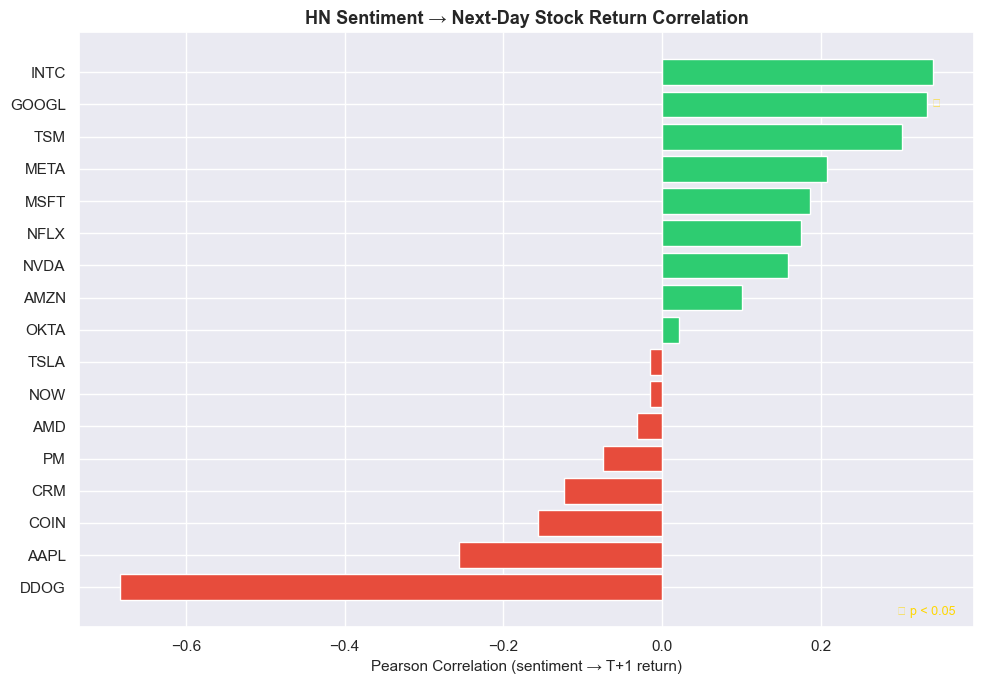

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
COLORS = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}

# ── Chart 1: Top correlating tickers (T+1) ────────────────────────────────
top_n   = df_results.nlargest(15, "corr_t1", keep="all")
bot_n   = df_results.nsmallest(5, "corr_t1", keep="all")
plot_df = pd.concat([top_n, bot_n]).drop_duplicates("ticker")
plot_df = plot_df.sort_values("corr_t1")

colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in plot_df["corr_t1"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_df["ticker"], plot_df["corr_t1"], color=colors, edgecolor="white")
ax.axvline(0, color="white", linewidth=0.8)
ax.set_xlabel("Pearson Correlation (sentiment → T+1 return)", fontsize=11)
ax.set_title("HN Sentiment → Next-Day Stock Return Correlation", fontsize=13, fontweight="bold")

# Mark statistically significant (p < 0.05)
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    if row["pval_t1"] < 0.05:
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                "★", va="center", fontsize=9, color="gold")

ax.text(0.98, 0.02, "★ p < 0.05", transform=ax.transAxes,
        ha="right", fontsize=9, color="gold")
plt.tight_layout()
plt.show()

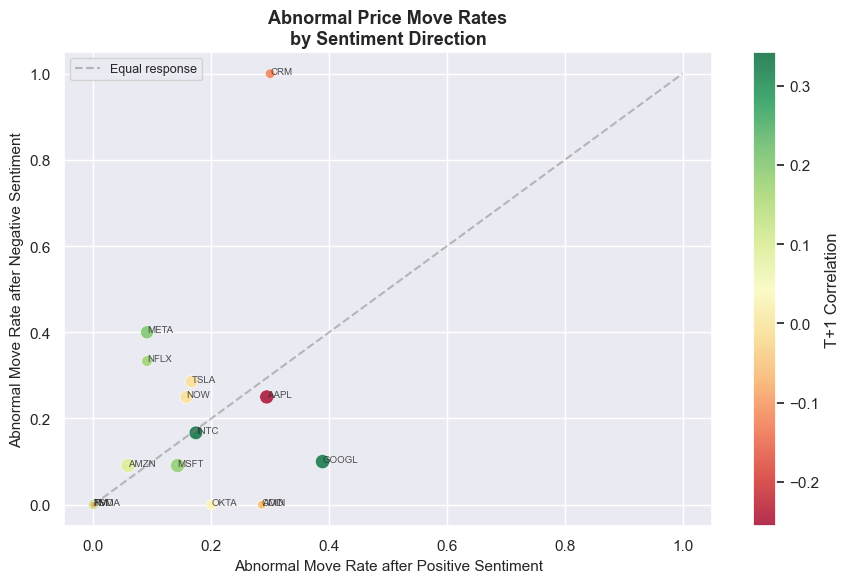

In [11]:
# ── Chart 2: Sentiment vs abnormal move rate ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    df_results["abnorm_pos"],
    df_results["abnorm_neg"],
    c=df_results["corr_t1"],
    cmap="RdYlGn",
    s=df_results["n_days"] * 3,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.5,
)
plt.colorbar(sc, label="T+1 Correlation")

for _, row in df_results.iterrows():
    ax.annotate(row["ticker"], (row["abnorm_pos"], row["abnorm_neg"]),
                fontsize=7, alpha=0.8)

ax.set_xlabel("Abnormal Move Rate after Positive Sentiment", fontsize=11)
ax.set_ylabel("Abnormal Move Rate after Negative Sentiment", fontsize=11)
ax.set_title("Abnormal Price Move Rates\nby Sentiment Direction", fontsize=13, fontweight="bold")
ax.plot([0,1],[0,1], "--", color="gray", alpha=0.5, label="Equal response")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

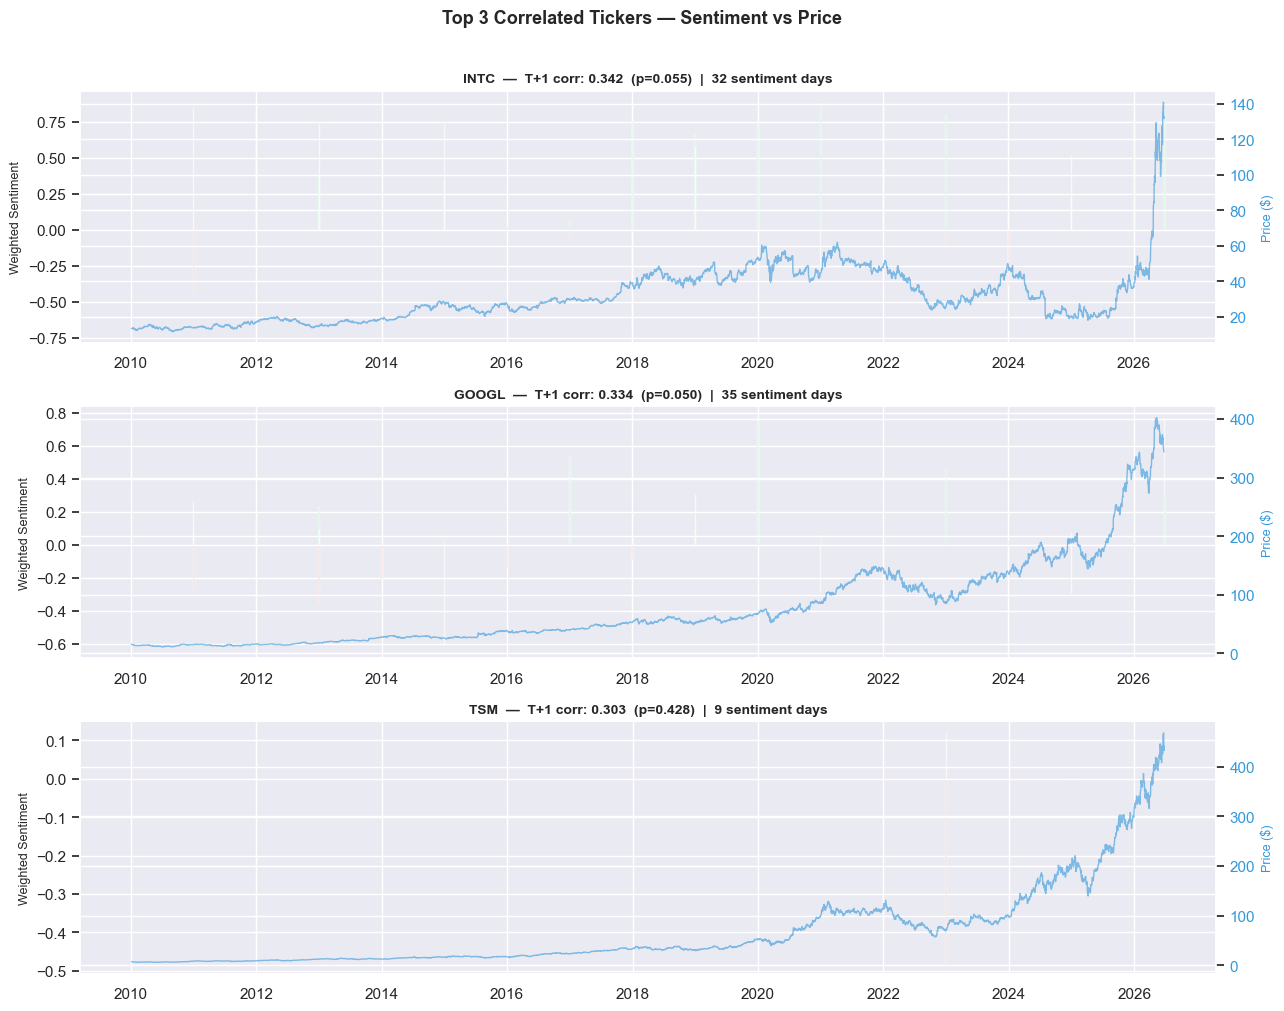

In [12]:
# ── Chart 3: Sentiment timeline for the top 3 correlating tickers ─────────
top3 = df_results.nlargest(3, "corr_t1")["ticker"].tolist()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)

for ax, ticker in zip(axes, top3):
    sent  = daily_sentiment[daily_sentiment["ticker"] == ticker].copy()
    price = df_prices[df_prices["ticker"] == ticker].copy()

    sent["date"]   = pd.to_datetime(sent["date"])
    price["Date"]  = pd.to_datetime(price["Date"])

    ax2 = ax.twinx()

    # Price line
    ax2.plot(price["Date"], price["Close"], color="#3498db", alpha=0.6,
             linewidth=1, label="Close price")
    ax2.set_ylabel("Price ($)", color="#3498db", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="#3498db")

    # Sentiment bars
    pos = sent[sent["norm_sentiment"] >= SENTIMENT_THRESHOLD]
    neg = sent[sent["norm_sentiment"] <= -SENTIMENT_THRESHOLD]
    neu = sent[(sent["norm_sentiment"] > -SENTIMENT_THRESHOLD) &
               (sent["norm_sentiment"] < SENTIMENT_THRESHOLD)]

    ax.bar(pos["date"], pos["norm_sentiment"],  color=COLORS["positive"], alpha=0.7, width=3)
    ax.bar(neg["date"], neg["norm_sentiment"],  color=COLORS["negative"], alpha=0.7, width=3)
    ax.bar(neu["date"], neu["norm_sentiment"],  color=COLORS["neutral"],  alpha=0.4, width=3)
    ax.axhline(0, color="white", linewidth=0.5)

    corr_row = df_results[df_results["ticker"] == ticker].iloc[0]
    ax.set_title(
        f"{ticker}  —  T+1 corr: {corr_row['corr_t1']:.3f}  "
        f"(p={corr_row['pval_t1']:.3f})  |  {corr_row['n_days']} sentiment days",
        fontsize=10, fontweight="bold"
    )
    ax.set_ylabel("Weighted Sentiment", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("Top 3 Correlated Tickers — Sentiment vs Price",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

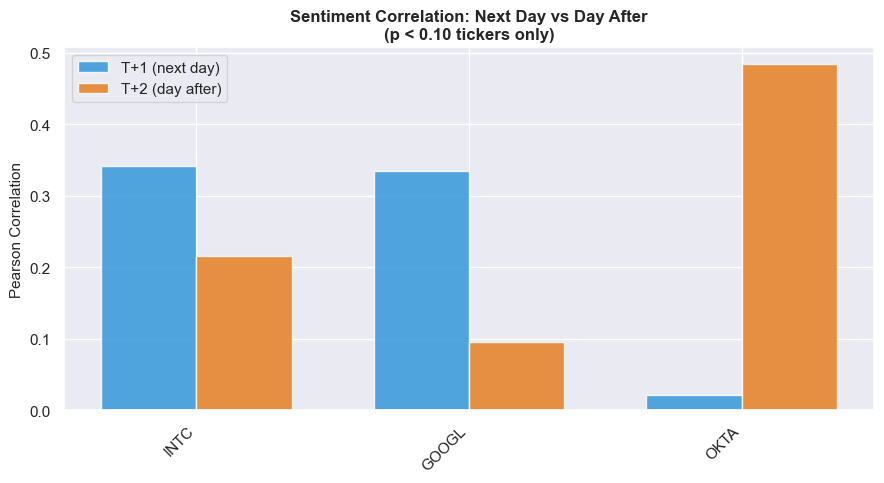

In [13]:
# ── Chart 4: T+1 vs T+2 correlation comparison ────────────────────────────
sig = df_results[(df_results["pval_t1"] < 0.1) | (df_results["pval_t2"] < 0.1)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(sig))
w = 0.35

ax.bar([i - w/2 for i in x], sig["corr_t1"], width=w,
       label="T+1 (next day)",   color="#3498db", alpha=0.85)
ax.bar([i + w/2 for i in x], sig["corr_t2"], width=w,
       label="T+2 (day after)",  color="#e67e22", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(sig["ticker"], rotation=45, ha="right")
ax.axhline(0, color="white", linewidth=0.6)
ax.set_ylabel("Pearson Correlation", fontsize=11)
ax.set_title("Sentiment Correlation: Next Day vs Day After\n(p < 0.10 tickers only)",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Summary table — strongest signals

In [14]:
summary = (
    df_results
    .assign(
        significant = df_results["pval_t1"] < 0.05,
        direction   = df_results["corr_t1"].apply(lambda x: "↑ positive" if x > 0 else "↓ negative"),
    )
    .sort_values("corr_t1", ascending=False, key=abs)
    [["ticker", "n_days", "corr_t1", "pval_t1", "corr_t2", "pval_t2",
      "abnorm_pos", "abnorm_neg", "direction", "significant"]]
    .head(20)
)

print("Top 20 tickers by absolute T+1 correlation:")
print("(significant = p < 0.05, abnorm_pos/neg = fraction of sentiment days with abnormal price move)\n")
summary

Top 20 tickers by absolute T+1 correlation:
(significant = p < 0.05, abnorm_pos/neg = fraction of sentiment days with abnormal price move)



,ticker,n_days,corr_t1,pval_t1,corr_t2,pval_t2,abnorm_pos,abnorm_neg,direction,significant
0,DDOG,5,-0.6833,0.2035,0.2616,0.6708,0.0000,NaN,↓ negative,False
1,INTC,32,0.3421,0.0553,0.2153,0.2367,0.1739,0.1667,↑ positive,False
2,GOOGL,35,0.3342,0.0498,0.0955,0.5854,0.3889,0.1000,↑ positive,True
3,TSM,9,0.3029,0.4283,-0.1039,0.7903,0.0000,0.0000,↑ positive,False
4,AAPL,34,-0.2560,0.1439,0.1942,0.2712,0.2941,0.2500,↓ negative,False
5,META,30,0.2086,0.2687,0.0494,0.7953,0.0909,0.4000,↑ positive,False
6,MSFT,35,0.1872,0.2815,-0.0439,0.8021,0.1429,0.0909,↑ positive,False
7,NFLX,20,0.1748,0.4611,0.2655,0.2580,0.0909,0.3333,↑ positive,False
8,NVDA,17,0.1584,0.5437,0.2914,0.2565,0.0000,0.0000,↑ positive,False
9,COIN,10,-0.1567,0.6654,0.3513,0.3196,0.2857,0.0000,↓ negative,False


---
# 📖 Plain English Section
## For anyone who just wants to understand what this data is saying

The charts below don't require any knowledge of finance, statistics, or tech.
The only thing you need to know: **buying a stock low and selling it high makes money.**

The big question we're asking: **If the internet was talking positively about a company on Monday, did that company's stock go up on Tuesday?**

In [15]:
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Global chart style: white background, faint gray grid ─────────────────
plt.rcParams.update({
    "figure.facecolor"   : "white",
    "axes.facecolor"     : "white",
    "axes.edgecolor"     : "#cccccc",
    "axes.grid"          : True,
    "grid.color"         : "#e8e8e8",
    "grid.linewidth"     : 0.7,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "font.family"        : "sans-serif",
})

# ── Color palette ──────────────────────────────────────────────────────────
C_POS     = "#27ae60"   # green  — positive buzz / buzz strategy
C_NEG     = "#e74c3c"   # red    — negative buzz
C_NEU     = "#bdc3c7"   # gray   — neutral buzz
C_PRICE   = "#2980b9"   # blue   — stock price line
C_BUZZ    = "#8e44ad"   # purple — buzz strategy line (dark, solid)
C_HOLD    = "#2c3e50"   # dark   — buy & hold line (dark, solid)
C_WIN_B   = "#a9dfbf"   # light green  — buzz strategy winning shading
C_WIN_H   = "#f5b7b1"   # light red    — buy & hold winning shading

# ── Setup: top 5 tickers ──────────────────────────────────────────────────
top5 = df_results.nlargest(5, "corr_t1", keep="all")["ticker"].tolist()
print("We'll focus on these 5 companies whose stock prices responded most to internet buzz:")
for t in top5:
    row  = df_results[df_results["ticker"]==t].iloc[0]
    name = COMPANY_MAP.get(t, {}).get("names", [t])[0].title()
    direction = "went UP" if row["corr_t1"] > 0 else "went DOWN"
    print(f"  {t:6s} ({name}) — when buzz was positive, stock {direction} next day ({row['corr_t1']:+.2f} correlation)")

We'll focus on these 5 companies whose stock prices responded most to internet buzz:
  INTC   (Intel) — when buzz was positive, stock went UP next day (+0.34 correlation)
  GOOGL  (Google) — when buzz was positive, stock went UP next day (+0.33 correlation)
  TSM    (Tsmc) — when buzz was positive, stock went UP next day (+0.30 correlation)
  META   (Meta) — when buzz was positive, stock went UP next day (+0.21 correlation)
  MSFT   (Microsoft) — when buzz was positive, stock went UP next day (+0.19 correlation)


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1222008716.py:53: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1222008716.py:53: UserWarning: Glyph 128528 (\N{NEUTRAL FACE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1222008716.py:53: UserWarning: Glyph 128543 (\N{WORRIED FACE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1222008716.py:53: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: U

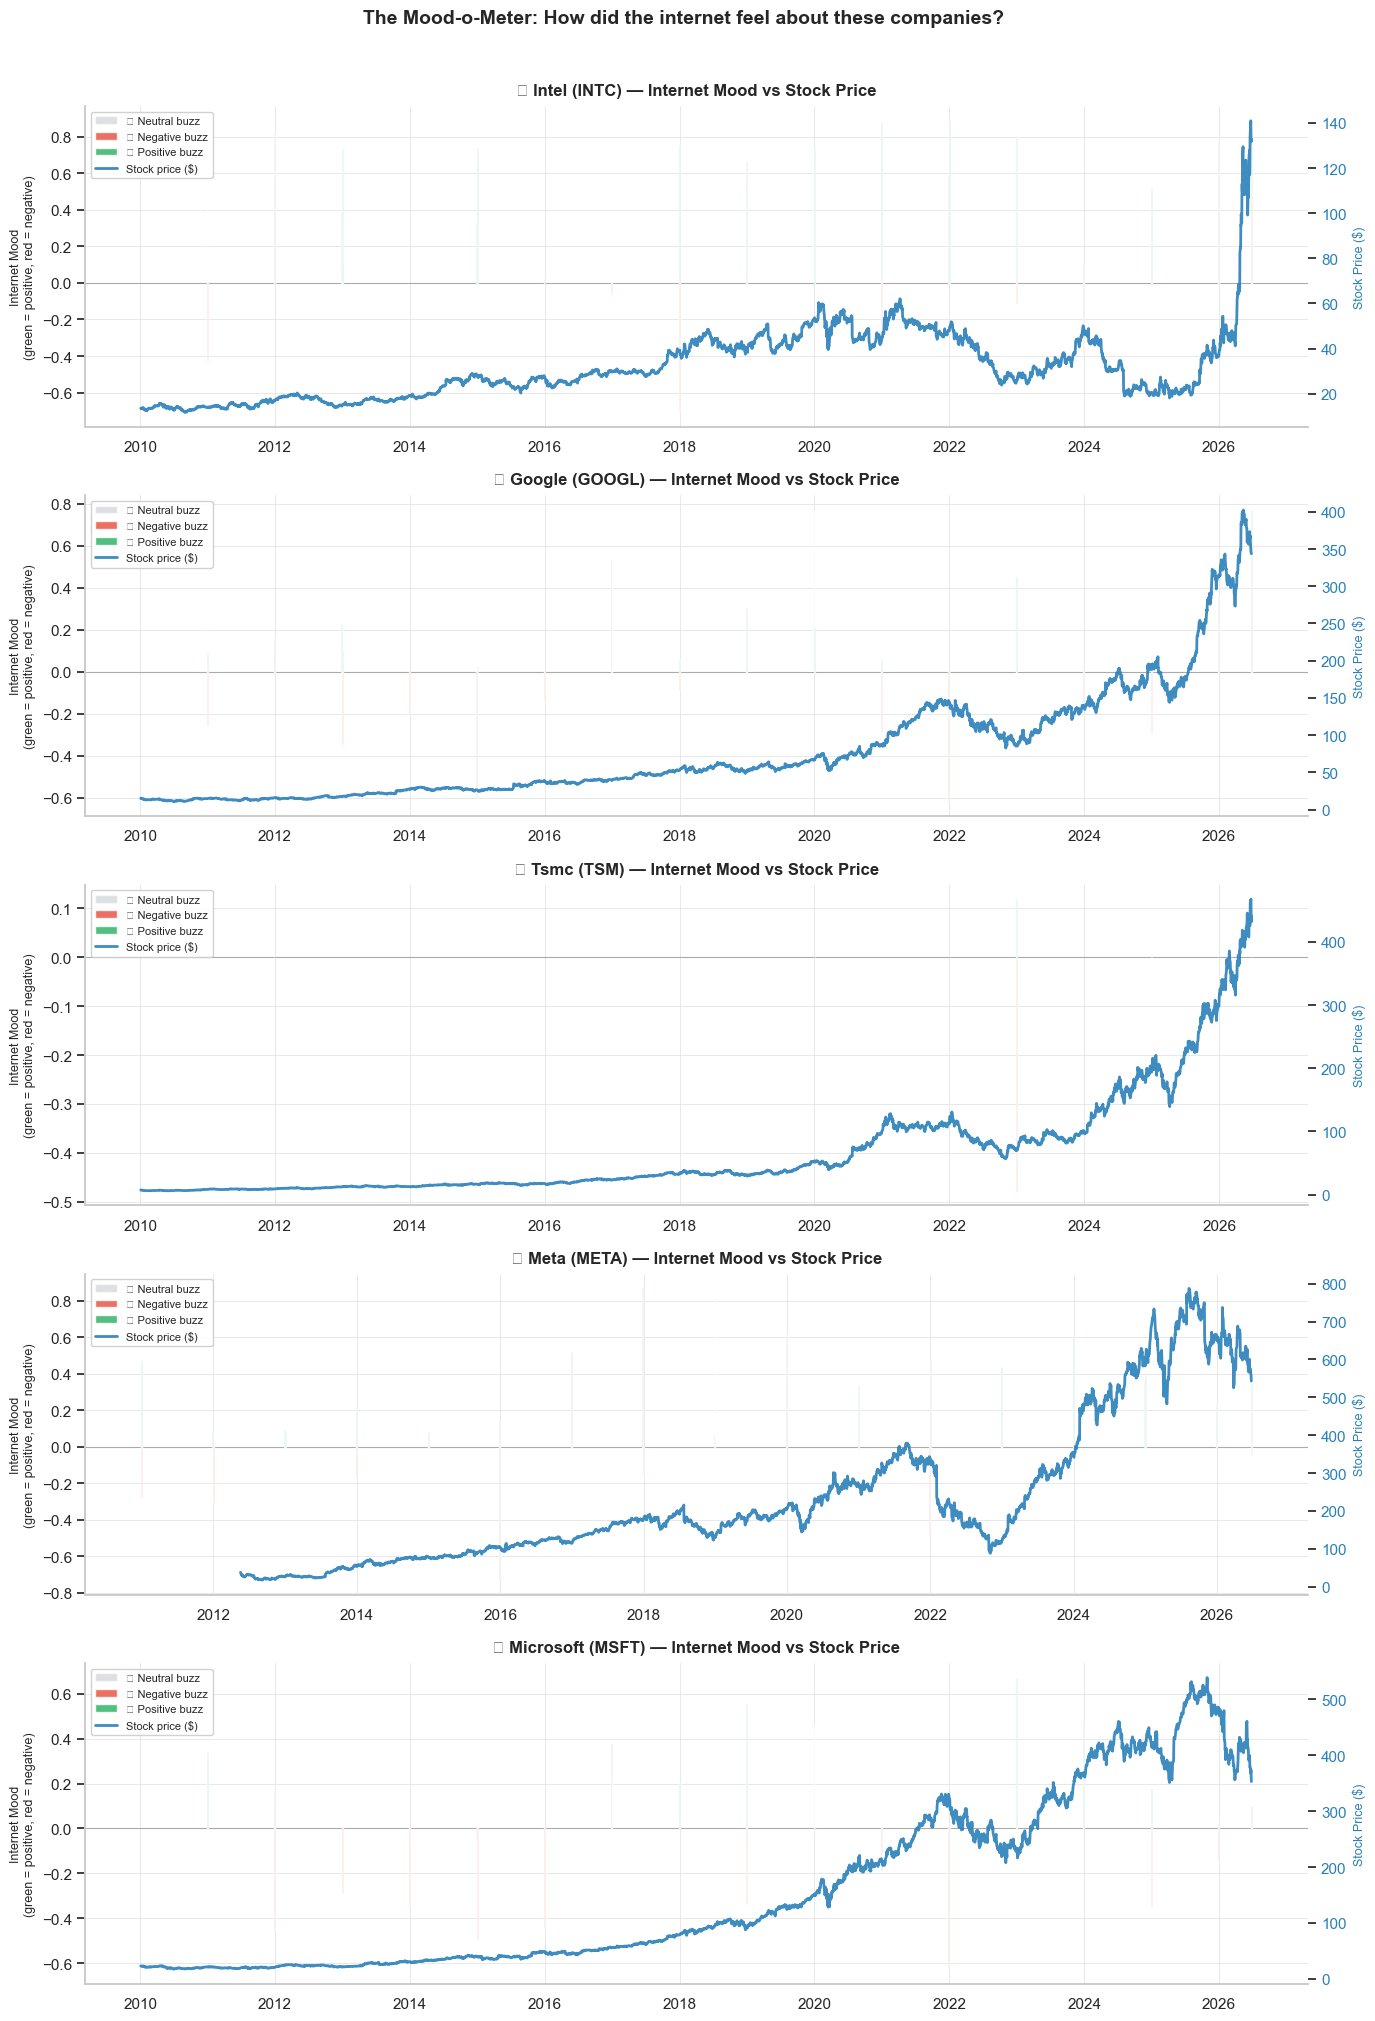

In [16]:
# ── Chart 11: The Mood-o-Meter ─────────────────────────────────────────────
# Green bars = positive buzz, Red bars = negative buzz, Gray bars = neutral
# Blue line = stock price. Bars drawn on top so they're always visible.

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4 * len(top5)),
                         facecolor="white")
if len(top5) == 1:
    axes = [axes]

for ax, ticker in zip(axes, top5):
    sent  = daily_sentiment[daily_sentiment["ticker"] == ticker].copy()
    price = df_prices[df_prices["ticker"] == ticker].copy()
    sent["date"]  = pd.to_datetime(sent["date"])
    price["Date"] = pd.to_datetime(price["Date"])
    name = COMPANY_MAP.get(ticker, {}).get("names", [ticker])[0].title()

    pos = sent[sent["norm_sentiment"] >= SENTIMENT_THRESHOLD]
    neg = sent[sent["norm_sentiment"] <= -SENTIMENT_THRESHOLD]
    neu = sent[(sent["norm_sentiment"] > -SENTIMENT_THRESHOLD) &
               (sent["norm_sentiment"] < SENTIMENT_THRESHOLD)]

    # Draw mood bars first (behind price)
    ax.bar(neu["date"], neu["norm_sentiment"], color=C_NEU,  alpha=0.5, width=5,
           label="😐 Neutral buzz",   zorder=2)
    ax.bar(neg["date"], neg["norm_sentiment"], color=C_NEG,  alpha=0.8, width=5,
           label="😟 Negative buzz",  zorder=3)
    ax.bar(pos["date"], pos["norm_sentiment"], color=C_POS,  alpha=0.8, width=5,
           label="😊 Positive buzz",  zorder=3)
    ax.axhline(0, color="#aaaaaa", linewidth=0.8, zorder=1)
    ax.set_ylabel("Internet Mood\n(green = positive, red = negative)", fontsize=9)
    ax.set_facecolor("white")

    # Price line on secondary axis (drawn on top)
    ax2 = ax.twinx()
    ax2.plot(price["Date"], price["Close"], color=C_PRICE, linewidth=2,
             alpha=0.9, label="Stock price ($)", zorder=4)
    ax2.set_ylabel("Stock Price ($)", fontsize=9, color=C_PRICE)
    ax2.tick_params(axis="y", labelcolor=C_PRICE)
    ax2.set_facecolor("white")
    ax2.grid(False)

    ax.set_title(f"📡 {name} ({ticker}) — Internet Mood vs Stock Price",
                 fontsize=12, fontweight="bold", pad=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left",
              fontsize=8, framealpha=0.9, facecolor="white")

fig.suptitle("The Mood-o-Meter: How did the internet feel about these companies?",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/3735475465.py:87: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/3735475465.py:87: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/3735475465.py:87: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/3735475465.py:87: UserWarning: Glyph 128558 (\N{FACE WITH OPEN MOUTH}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/3735475465.py:87: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/3735475465.py:87: UserWarning: Glyph 

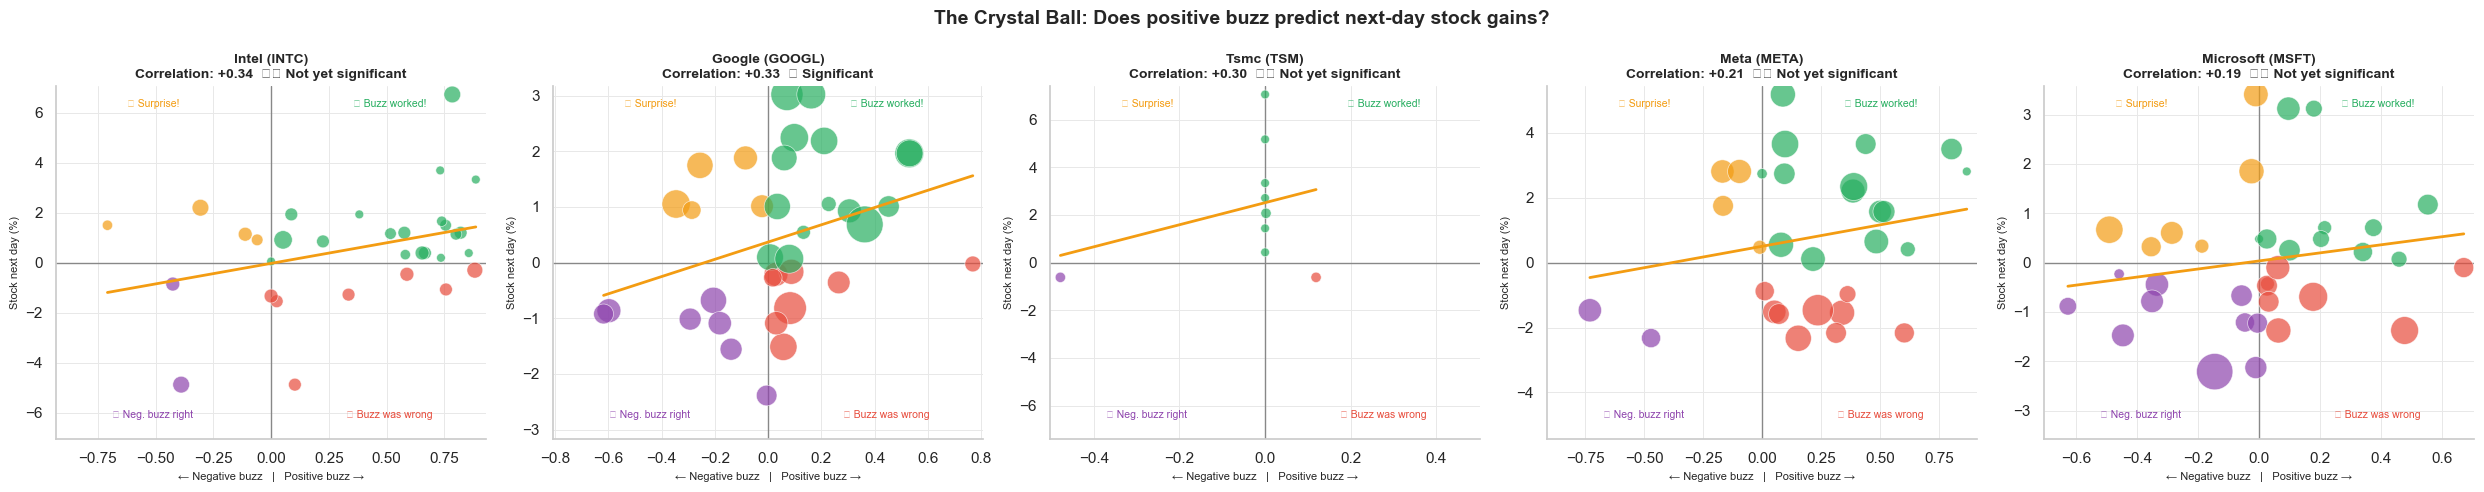


💡 Each dot = one day. Top-right quadrant = positive buzz AND stock went up (buzz worked!).
   Bigger dot = more stories that day. Orange trend line = overall direction.


In [17]:
# ── Chart 12: The Crystal Ball — quadrant view ────────────────────────────
# Divides into 4 quadrants:
#   Top-right    = positive buzz, stock went UP   ✅ buzz worked!
#   Bottom-right = positive buzz, stock went DOWN  ❌ buzz was wrong
#   Top-left     = negative buzz, stock went UP    😮 surprise!
#   Bottom-left  = negative buzz, stock went DOWN  ✅ negative buzz was right

ncols = min(5, len(top5))
nrows = (len(top5) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 5 * nrows),
                         facecolor="white")
axes_flat = np.array(axes).flatten() if len(top5) > 1 else [axes]

for ax, ticker in zip(axes_flat, top5):
    sent  = daily_sentiment[daily_sentiment["ticker"] == ticker].copy()
    price = df_prices[df_prices["ticker"] == ticker].copy()
    sent["date"]  = pd.to_datetime(sent["date"])
    price         = price.set_index("Date").sort_index()
    name = COMPANY_MAP.get(ticker, {}).get("names", [ticker])[0].title()

    rows = []
    for _, srow in sent.iterrows():
        future = price.index[price.index > srow["date"]][:1]
        if len(future) == 0:
            continue
        ret = price.loc[future[0], "daily_return"] * 100
        rows.append({"sentiment": srow["norm_sentiment"],
                     "next_day_pct": ret,
                     "stories": srow["story_count"]})

    df_plot = pd.DataFrame(rows).dropna()
    if df_plot.empty:
        ax.set_visible(False)
        continue

    # Color by quadrant
    dot_colors = [
        C_POS if (s >= 0 and r >= 0) else
        C_NEG if (s >= 0 and r < 0)  else
        "#f39c12" if (s < 0 and r >= 0) else
        "#8e44ad"
        for s, r in zip(df_plot["sentiment"], df_plot["next_day_pct"])
    ]

    ax.scatter(df_plot["sentiment"], df_plot["next_day_pct"],
               c=dot_colors, alpha=0.7, s=df_plot["stories"]*15+25,
               edgecolors="white", linewidths=0.5, zorder=3)

    # Trend line (solid)
    if len(df_plot) > 3:
        z  = np.polyfit(df_plot["sentiment"], df_plot["next_day_pct"], 1)
        p  = np.poly1d(z)
        xs = np.linspace(df_plot["sentiment"].min(), df_plot["sentiment"].max(), 100)
        ax.plot(xs, p(xs), color="#f39c12", linewidth=2, zorder=4)

    # Quadrant lines
    ax.axhline(0, color="#888888", linewidth=1, zorder=2)
    ax.axvline(0, color="#888888", linewidth=1, zorder=2)

    # Quadrant labels
    xmax = df_plot["sentiment"].abs().max() * 1.05
    ymax = df_plot["next_day_pct"].abs().max() * 1.05
    ax.set_xlim(-xmax, xmax)
    ax.set_ylim(-ymax, ymax)

    ax.text( xmax*0.55,  ymax*0.88, "✅ Buzz worked!",     fontsize=7.5, color=C_POS,    ha="center")
    ax.text(-xmax*0.55,  ymax*0.88, "😮 Surprise!",        fontsize=7.5, color="#f39c12", ha="center")
    ax.text( xmax*0.55, -ymax*0.88, "❌ Buzz was wrong",   fontsize=7.5, color=C_NEG,    ha="center")
    ax.text(-xmax*0.55, -ymax*0.88, "📉 Neg. buzz right",  fontsize=7.5, color="#8e44ad", ha="center")

    ax.set_xlabel("← Negative buzz   |   Positive buzz →", fontsize=8)
    ax.set_ylabel("Stock next day (%)", fontsize=8)
    ax.set_facecolor("white")

    corr_row = df_results[df_results["ticker"]==ticker].iloc[0]
    sig = "✅ Significant" if corr_row["pval_t1"] < 0.05 else "⚠️ Not yet significant"
    ax.set_title(f"{name} ({ticker})\nCorrelation: {corr_row['corr_t1']:+.2f}  {sig}",
                 fontsize=10, fontweight="bold")

# Hide unused axes
for ax in axes_flat[len(top5):]:
    ax.set_visible(False)

fig.suptitle("The Crystal Ball: Does positive buzz predict next-day stock gains?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n💡 Each dot = one day. Top-right quadrant = positive buzz AND stock went up (buzz worked!).")
print("   Bigger dot = more stories that day. Orange trend line = overall direction.")

Font 'default' does not have a glyph for '\U0001f9e0' [U+1f9e0], substituting with a dummy symbol.
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/2984066179.py:91: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/2984066179.py:91: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  plt.tight_layout()
Font 'default' does not have a glyph for '\U0001f4e6' [U+1f4e6], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4e6' [U+1f4e6], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f9e0' [U+1f9e0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4e6' [U+1f4e6], substituting with a dummy symbol.
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/2984066179.py:91: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_l

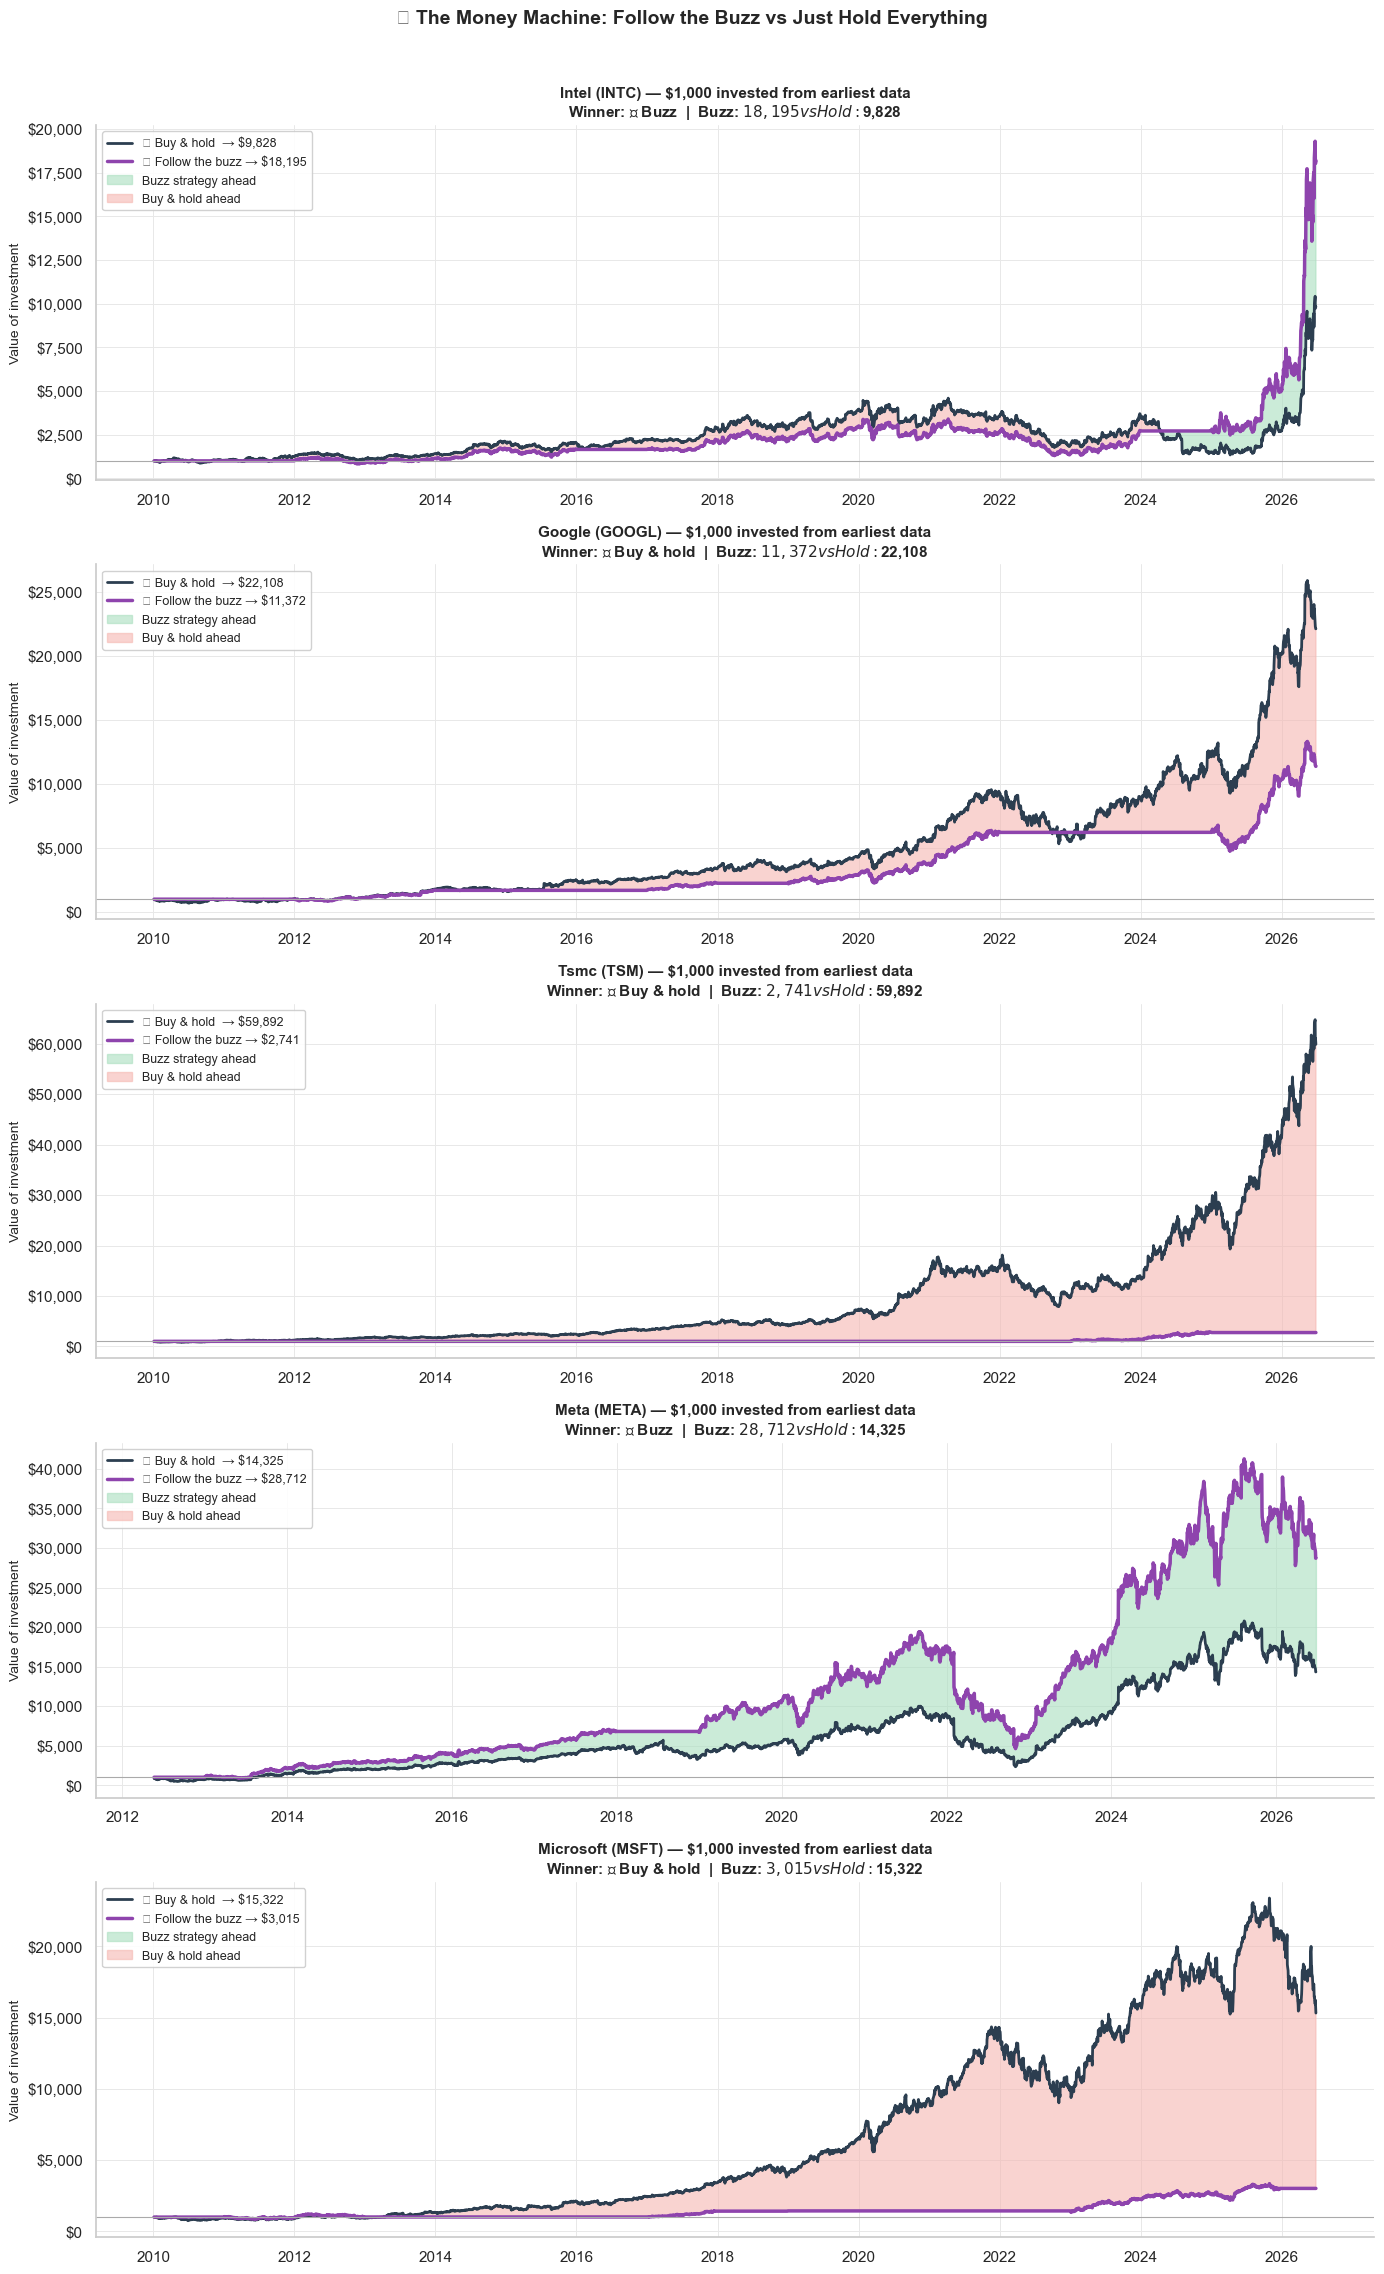


💡 Investment start: earliest available data
   Dark lines = the two strategies. Light green = buzz winning. Light red = hold winning.
   To try a different start date, change INVESTMENT_START_DATE at the top of this cell.


In [18]:
# ── Chart 13: The Money Machine ───────────────────────────────────────────
# ┌──────────────────────────────────────────────────────────┐
# │ INVESTMENT_START_DATE — change this to try different     │
# │ starting points. Format: "YYYY-MM-DD"                    │
# │ Use None to start from the earliest available data.      │
# └──────────────────────────────────────────────────────────┘
INVESTMENT_START_DATE = None          # ← CHANGE THIS  e.g. "2018-01-01"
STARTING_CASH         = 1000

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4.5 * len(top5)),
                         facecolor="white")
if len(top5) == 1:
    axes = [axes]

strategy_summary = []

for ax, ticker in zip(axes, top5):
    sent  = daily_sentiment[daily_sentiment["ticker"] == ticker].copy()
    price = df_prices[df_prices["ticker"] == ticker].copy()
    sent["date"]  = pd.to_datetime(sent["date"])
    price         = price.set_index("Date").sort_index()
    name = COMPANY_MAP.get(ticker, {}).get("names", [ticker])[0].title()

    # Apply start date filter
    if INVESTMENT_START_DATE:
        start = pd.Timestamp(INVESTMENT_START_DATE)
        price = price[price.index >= start]
        sent  = sent[sent["date"] >= start]

    buzz_wallet    = STARTING_CASH
    holdall_wallet = STARTING_CASH
    buzz_history    = []
    holdall_history = []
    dates_used      = []
    sent_idx = sent.set_index("date").sort_index()

    for date in price.index:
        ret = price.loc[date, "daily_return"]
        if pd.isna(ret):
            continue
        holdall_wallet *= (1 + ret)
        yesterday   = date - pd.Timedelta(days=1)
        prior_dates = sent_idx.index[sent_idx.index <= yesterday]
        if len(prior_dates) > 0:
            prior_sent = sent_idx.loc[prior_dates[-1], "norm_sentiment"]
            if prior_sent >= SENTIMENT_THRESHOLD:
                buzz_wallet *= (1 + ret)
        buzz_history.append(buzz_wallet)
        holdall_history.append(holdall_wallet)
        dates_used.append(date)

    buzz_final    = buzz_wallet
    holdall_final = holdall_wallet
    strategy_summary.append({
        "ticker"        : ticker,
        "name"          : name,
        "buzz_final"    : round(buzz_final, 2),
        "holdall_final" : round(holdall_final, 2),
        "buzz_profit"   : round(buzz_final - STARTING_CASH, 2),
        "holdall_profit": round(holdall_final - STARTING_CASH, 2),
        "buzz_wins"     : buzz_final > holdall_final,
    })

    # Solid lines — dark colors for strategies, light fill for winning zones
    ax.plot(dates_used, holdall_history, color=C_HOLD, linewidth=2,
            label=f"📦 Buy & hold  → ${holdall_final:,.0f}")
    ax.plot(dates_used, buzz_history,   color=C_BUZZ, linewidth=2.5,
            label=f"🧠 Follow the buzz → ${buzz_final:,.0f}")
    ax.fill_between(dates_used, holdall_history, buzz_history,
                    where=[b > h for b, h in zip(buzz_history, holdall_history)],
                    color=C_WIN_B, alpha=0.6, label="Buzz strategy ahead")
    ax.fill_between(dates_used, holdall_history, buzz_history,
                    where=[b < h for b, h in zip(buzz_history, holdall_history)],
                    color=C_WIN_H, alpha=0.6, label="Buy & hold ahead")
    ax.axhline(STARTING_CASH, color="#aaaaaa", linewidth=0.8)

    ax.set_ylabel("Value of investment", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.set_facecolor("white")
    winner = "🧠 Buzz" if buzz_final > holdall_final else "📦 Buy & hold"
    start_label = INVESTMENT_START_DATE or "earliest data"
    ax.set_title(
        f"{name} ({ticker}) — ${STARTING_CASH:,} invested from {start_label}\n"
        f"Winner: {winner}  |  Buzz: ${buzz_final:,.0f}  vs  Hold: ${holdall_final:,.0f}",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=9, loc="upper left", facecolor="white", framealpha=0.9)

fig.suptitle("💰 The Money Machine: Follow the Buzz vs Just Hold Everything",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print(f"\n💡 Investment start: {INVESTMENT_START_DATE or 'earliest available data'}")
print("   Dark lines = the two strategies. Light green = buzz winning. Light red = hold winning.")
print("   To try a different start date, change INVESTMENT_START_DATE at the top of this cell.")

In [19]:
# ── Chart 14: Report card ─────────────────────────────────────────────────
df_summary = pd.DataFrame(strategy_summary)
df_summary["buzz_return"]    = ((df_summary["buzz_final"]    / STARTING_CASH - 1) * 100).round(1)
df_summary["holdall_return"] = ((df_summary["holdall_final"] / STARTING_CASH - 1) * 100).round(1)
df_summary["extra_profit"]   = (df_summary["buzz_final"] - df_summary["holdall_final"]).round(2)

print("=" * 75)
print(f"📊 REPORT CARD — Starting with ${STARTING_CASH:,}, following the buzz...")
print("=" * 75)
for _, row in df_summary.iterrows():
    print(f"\n  {row['name'].upper()} ({row['ticker']})")
    print(f"    Follow-the-buzz : ${row['buzz_final']:>9,.2f}  ({row['buzz_return']:+.1f}%)")
    print(f"    Buy & hold      : ${row['holdall_final']:>9,.2f}  ({row['holdall_return']:+.1f}%)")
    diff = row["extra_profit"]
    if diff > 0:
        print(f"    ✅ Buzz strategy made you ${diff:,.2f} EXTRA")
    else:
        print(f"    ❌ Buzz strategy cost you ${abs(diff):,.2f} vs just holding")
print("\n" + "=" * 75)
winners = df_summary[df_summary["buzz_wins"]].shape[0]
print(f"\n  Buzz strategy beat buy-and-hold in {winners} out of {len(df_summary)} companies.")
print("\n  ⚠️  This is for learning purposes only — not financial advice!")

📊 REPORT CARD — Starting with $1,000, following the buzz...

  INTEL (INTC)
    Follow-the-buzz : $18,194.92  (+1719.5%)
    Buy & hold      : $ 9,828.08  (+882.8%)
    ✅ Buzz strategy made you $8,366.84 EXTRA

  GOOGLE (GOOGL)
    Follow-the-buzz : $11,371.96  (+1037.2%)
    Buy & hold      : $22,108.40  (+2110.8%)
    ❌ Buzz strategy cost you $10,736.44 vs just holding

  TSMC (TSM)
    Follow-the-buzz : $ 2,741.02  (+174.1%)
    Buy & hold      : $59,891.64  (+5889.2%)
    ❌ Buzz strategy cost you $57,150.62 vs just holding

  META (META)
    Follow-the-buzz : $28,711.90  (+2771.2%)
    Buy & hold      : $14,324.80  (+1332.5%)
    ✅ Buzz strategy made you $14,387.10 EXTRA

  MICROSOFT (MSFT)
    Follow-the-buzz : $ 3,014.79  (+201.5%)
    Buy & hold      : $15,322.11  (+1432.2%)
    ❌ Buzz strategy cost you $12,307.32 vs just holding


  Buzz strategy beat buy-and-hold in 2 out of 5 companies.

  ⚠️  This is for learning purposes only — not financial advice!


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/658000457.py:39: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/658000457.py:39: UserWarning: Glyph 128522 (\N{SMILING FACE WITH SMILING EYES}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/658000457.py:39: UserWarning: Glyph 128528 (\N{NEUTRAL FACE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/658000457.py:39: UserWarning: Glyph 128543 (\N{WORRIED FACE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128522 (

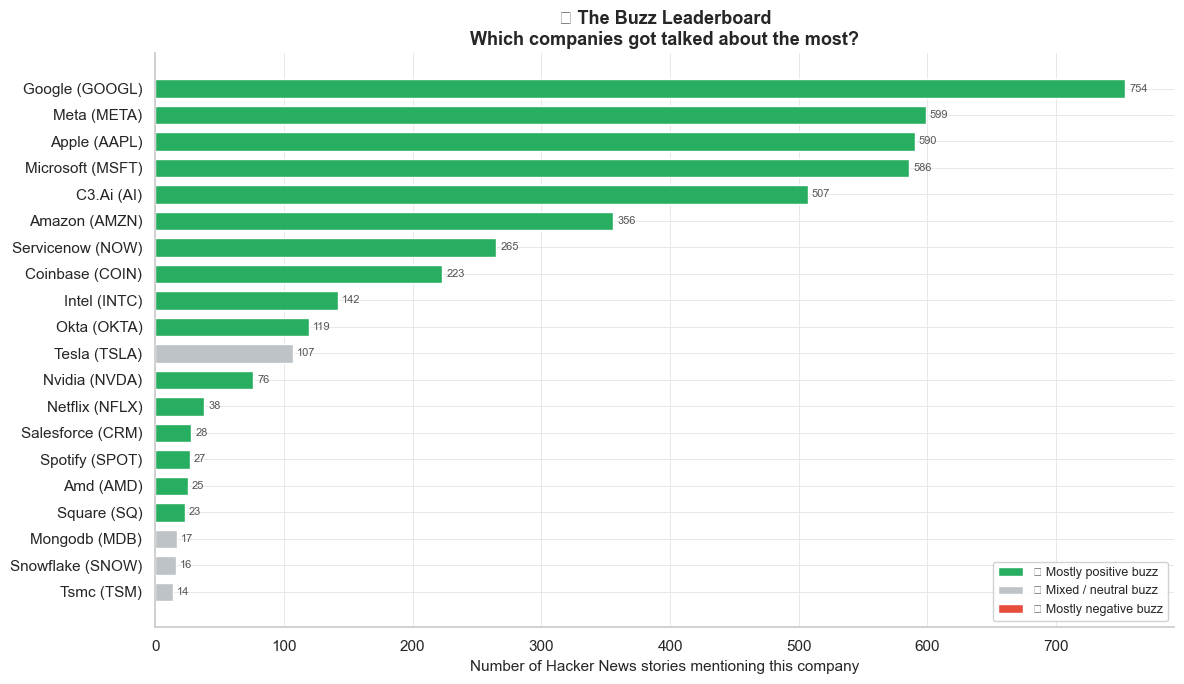


💡 Longer bar = more stories. Green = mostly positive talk. Red = mostly negative. Gray = mixed.


In [20]:
# ── Chart 15: The Buzz Leaderboard ────────────────────────────────────────
buzz_totals = (
    df_matches.groupby("ticker")
    .agg(
        total_stories = ("id",             "count"),
        avg_sentiment = ("sentiment",       "mean"),
        pos_stories   = ("sentiment_label", lambda x: (x=="positive").sum()),
        neg_stories   = ("sentiment_label", lambda x: (x=="negative").sum()),
    )
    .reset_index()
    .sort_values("total_stories", ascending=False)
    .head(20)
)
buzz_totals["company"] = buzz_totals["ticker"].apply(
    lambda t: COMPANY_MAP.get(t, {}).get("names", [t])[0].title() + f" ({t})"
)
bar_colors = [
    C_POS if s > 0.05 else (C_NEG if s < -0.05 else C_NEU)
    for s in buzz_totals["avg_sentiment"]
]

fig, ax = plt.subplots(figsize=(12, 7), facecolor="white")
bars = ax.barh(buzz_totals["company"][::-1], buzz_totals["total_stories"][::-1],
               color=bar_colors[::-1], edgecolor="white", height=0.7)
for bar, val in zip(bars, buzz_totals["total_stories"][::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8, color="#555555")
ax.set_xlabel("Number of Hacker News stories mentioning this company", fontsize=11)
ax.set_title("🏆 The Buzz Leaderboard\nWhich companies got talked about the most?",
             fontsize=13, fontweight="bold")
ax.set_facecolor("white")
legend_elements = [
    Patch(facecolor=C_POS, label="😊 Mostly positive buzz"),
    Patch(facecolor=C_NEU, label="😐 Mixed / neutral buzz"),
    Patch(facecolor=C_NEG, label="😟 Mostly negative buzz"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9,
          facecolor="white", framealpha=0.9)
plt.tight_layout()
plt.show()
print("\n💡 Longer bar = more stories. Green = mostly positive talk. Red = mostly negative. Gray = mixed.")

---
# 📅 Stock Lifecycle Analysis
## Does buzz work better at different stages of a company's life?

A company that just listed on the stock market is very different from one that's been around for 20 years.
A stock trading near its all-time high is in a different place than one near its all-time low.

This section asks: **does following the buzz work better at some points in a stock's life than others?**

We look at two dimensions:
- **Age** — how many years since the stock was first listed
- **Price stage** — is the stock near its historical low, middle, or near its all-time high?

In [21]:
# ── Build lifecycle features for every ticker-day in df_matches ───────────
print("Building lifecycle features ...")

lifecycle_rows = []

for ticker in df_results["ticker"].unique():
    sent  = daily_sentiment[daily_sentiment["ticker"] == ticker].copy()
    price = df_prices[df_prices["ticker"] == ticker].copy()
    if sent.empty or price.empty:
        continue

    sent["date"]  = pd.to_datetime(sent["date"])
    price["Date"] = pd.to_datetime(price["Date"])
    price         = price.sort_values("Date").set_index("Date")

    # Age = years since first available price date
    first_date = price.index.min()

    # All-time high and low for price stage calculation
    all_time_high = price["Close"].max()
    all_time_low  = price["Close"].min()
    price_range   = all_time_high - all_time_low

    for _, srow in sent.iterrows():
        date = pd.Timestamp(srow["date"])

        # Get next-day return
        future = price.index[price.index > date][:1]
        if len(future) == 0:
            continue
        ret_t1 = price.loc[future[0], "daily_return"]
        if pd.isna(ret_t1):
            continue

        # Current close on sentiment day
        past = price.index[price.index <= date]
        if len(past) == 0:
            continue
        current_close = price.loc[past[-1], "Close"]

        # Age in years at this date
        age_years = (date - first_date).days / 365.25

        # Price stage: where is current price in its own all-time range? (0=low, 1=high)
        price_pct = (current_close - all_time_low) / price_range if price_range > 0 else 0.5

        # Buckets
        if age_years < 3:
            age_bucket = "Young (0-3 yrs)"
        elif age_years < 8:
            age_bucket = "Growing (3-8 yrs)"
        elif age_years < 15:
            age_bucket = "Established (8-15 yrs)"
        else:
            age_bucket = "Mature (15+ yrs)"

        if price_pct < 0.25:
            price_stage = "Near all-time low"
        elif price_pct < 0.60:
            price_stage = "Mid-range"
        elif price_pct < 0.85:
            price_stage = "Upper range"
        else:
            price_stage = "Near all-time high"

        lifecycle_rows.append({
            "ticker"       : ticker,
            "date"         : date,
            "sentiment"    : srow["norm_sentiment"],
            "ret_t1"       : ret_t1 * 100,
            "age_years"    : round(age_years, 1),
            "age_bucket"   : age_bucket,
            "price_pct"    : round(price_pct, 3),
            "price_stage"  : price_stage,
            "story_count"  : srow["story_count"],
        })

df_lifecycle = pd.DataFrame(lifecycle_rows)
print(f"✓ Lifecycle dataset: {len(df_lifecycle):,} ticker-days")
df_lifecycle.head()

Building lifecycle features ...
✓ Lifecycle dataset: 373 ticker-days


,ticker,date,sentiment,ret_t1,age_years,age_bucket,price_pct,price_stage,story_count
0,DDOG,2019-12-31,0.9656,-2.858650,0.3,Young (0-3 yrs),0.039,Near all-time low,1
1,DDOG,2022-12-30,0.3612,-1.918372,3.3,Growing (3-8 yrs),0.182,Near all-time low,1
2,DDOG,2024-12-30,0.5423,-0.887840,5.3,Growing (3-8 yrs),0.466,Mid-range,1
3,DDOG,2024-12-31,0.0000,0.517885,5.3,Growing (3-8 yrs),0.460,Mid-range,1
4,DDOG,2025-12-31,0.0000,-1.632474,6.3,Growing (3-8 yrs),0.433,Mid-range,1


/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/3119772409.py:69: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


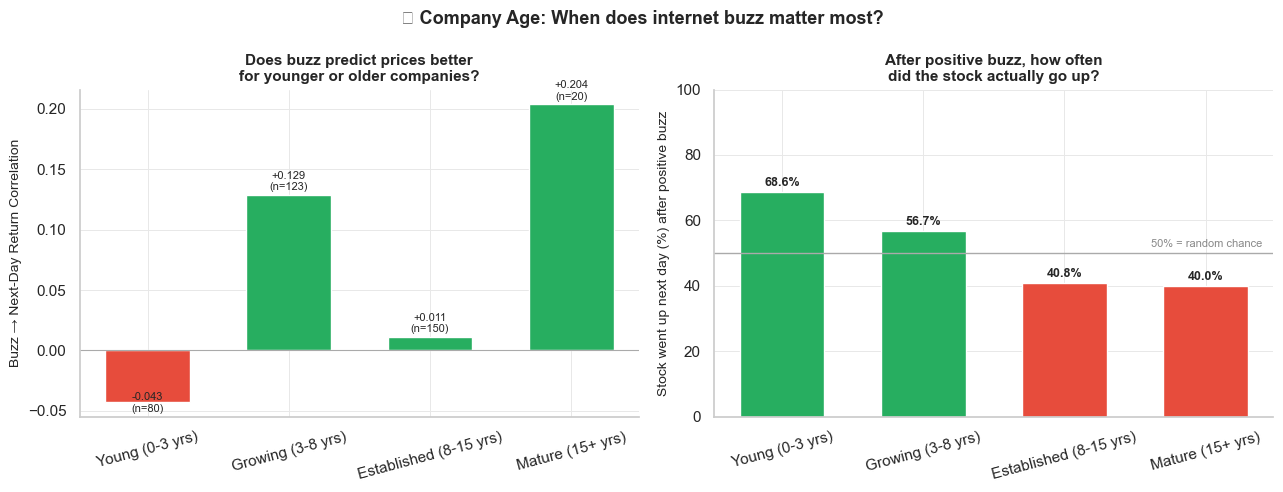


💡 Above 50% on the right chart = buzz was useful (better than random guessing).
   If young companies score higher, buzz matters more early in a stock's life.


In [22]:
# ── Chart 16: Does buzz work better for young vs old companies? ───────────
# For each age bucket, show the correlation between buzz and next-day return

from scipy import stats

age_order = ["Young (0-3 yrs)", "Growing (3-8 yrs)",
             "Established (8-15 yrs)", "Mature (15+ yrs)"]

age_corrs = []
for bucket in age_order:
    sub = df_lifecycle[df_lifecycle["age_bucket"] == bucket].dropna()
    if len(sub) < 10:
        continue
    r, p = stats.pearsonr(sub["sentiment"], sub["ret_t1"])
    # Buzz strategy win rate in this bucket
    pos_buzz = sub[sub["sentiment"] >= SENTIMENT_THRESHOLD]
    win_rate = (pos_buzz["ret_t1"] > 0).mean() if len(pos_buzz) > 0 else np.nan
    age_corrs.append({
        "bucket"   : bucket,
        "corr"     : round(r, 4),
        "pval"     : round(p, 4),
        "n"        : len(sub),
        "win_rate" : round(win_rate, 3),
    })

df_age = pd.DataFrame(age_corrs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")

# Left: correlation by age
ax = axes[0]
bar_colors = [C_POS if v > 0 else C_NEG for v in df_age["corr"]]
bars = ax.bar(df_age["bucket"], df_age["corr"], color=bar_colors,
              edgecolor="white", width=0.6)
ax.axhline(0, color="#aaaaaa", linewidth=0.8)
ax.set_ylabel("Buzz → Next-Day Return Correlation", fontsize=10)
ax.set_title("Does buzz predict prices better\nfor younger or older companies?",
             fontsize=11, fontweight="bold")
ax.set_facecolor("white")
ax.tick_params(axis="x", labelrotation=15)
for bar, row in zip(bars, df_age.itertuples()):
    label = f"{row.corr:+.3f}\n(n={row.n:,})"
    ypos  = bar.get_height() + 0.002 if row.corr >= 0 else bar.get_height() - 0.01
    ax.text(bar.get_x() + bar.get_width()/2, ypos, label,
            ha="center", va="bottom", fontsize=8)

# Right: win rate by age (when buzz was positive, how often did stock go up?)
ax = axes[1]
win_colors = [C_POS if v >= 0.5 else C_NEG for v in df_age["win_rate"]]
bars2 = ax.bar(df_age["bucket"], df_age["win_rate"] * 100,
               color=win_colors, edgecolor="white", width=0.6)
ax.axhline(50, color="#aaaaaa", linewidth=1, linestyle="-")
ax.text(0.98, 0.52, "50% = random chance", transform=ax.transAxes,
        ha="right", fontsize=8, color="#888888")
ax.set_ylabel("Stock went up next day (%) after positive buzz", fontsize=10)
ax.set_title("After positive buzz, how often\ndid the stock actually go up?",
             fontsize=11, fontweight="bold")
ax.set_facecolor("white")
ax.tick_params(axis="x", labelrotation=15)
ax.set_ylim(0, 100)
for bar, row in zip(bars2, df_age.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{row.win_rate*100:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

fig.suptitle("📅 Company Age: When does internet buzz matter most?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n💡 Above 50% on the right chart = buzz was useful (better than random guessing).")
print("   If young companies score higher, buzz matters more early in a stock's life.")

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1146870030.py:64: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1146870030.py:64: UserWarning: Glyph 10145 (\N{BLACK RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1146870030.py:64: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1146870030.py:64: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1146870030.py:64: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/1146870030.py:64: U

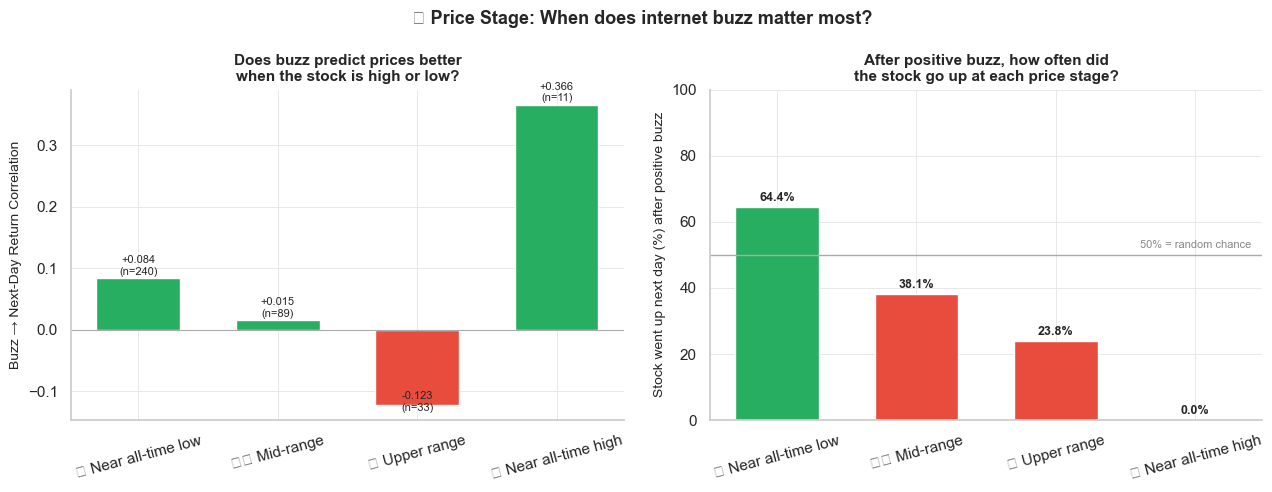


💡 'Near all-time low' = the stock is cheap vs its own history.
   'Near all-time high' = the stock is expensive vs its own history.
   This shows whether buzz is more useful when a stock is cheap or when it's flying high.


In [23]:
# ── Chart 17: Does buzz work better at different price stages? ────────────

stage_order = ["Near all-time low", "Mid-range", "Upper range", "Near all-time high"]
stage_emojis = {"Near all-time low": "📉", "Mid-range": "➡️",
                "Upper range": "📈", "Near all-time high": "🚀"}

stage_corrs = []
for stage in stage_order:
    sub = df_lifecycle[df_lifecycle["price_stage"] == stage].dropna()
    if len(sub) < 10:
        continue
    r, p = stats.pearsonr(sub["sentiment"], sub["ret_t1"])
    pos_buzz = sub[sub["sentiment"] >= SENTIMENT_THRESHOLD]
    win_rate = (pos_buzz["ret_t1"] > 0).mean() if len(pos_buzz) > 0 else np.nan
    stage_corrs.append({
        "stage"    : f"{stage_emojis[stage]} {stage}",
        "corr"     : round(r, 4),
        "pval"     : round(p, 4),
        "n"        : len(sub),
        "win_rate" : round(win_rate, 3),
    })

df_stage = pd.DataFrame(stage_corrs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")

ax = axes[0]
bar_colors = [C_POS if v > 0 else C_NEG for v in df_stage["corr"]]
bars = ax.bar(df_stage["stage"], df_stage["corr"],
              color=bar_colors, edgecolor="white", width=0.6)
ax.axhline(0, color="#aaaaaa", linewidth=0.8)
ax.set_ylabel("Buzz → Next-Day Return Correlation", fontsize=10)
ax.set_title("Does buzz predict prices better\nwhen the stock is high or low?",
             fontsize=11, fontweight="bold")
ax.set_facecolor("white")
ax.tick_params(axis="x", labelrotation=15)
for bar, row in zip(bars, df_stage.itertuples()):
    label = f"{row.corr:+.3f}\n(n={row.n:,})"
    ypos  = bar.get_height() + 0.002 if row.corr >= 0 else bar.get_height() - 0.012
    ax.text(bar.get_x() + bar.get_width()/2, ypos, label,
            ha="center", va="bottom", fontsize=8)

ax = axes[1]
win_colors = [C_POS if v >= 0.5 else C_NEG for v in df_stage["win_rate"]]
bars2 = ax.bar(df_stage["stage"], df_stage["win_rate"] * 100,
               color=win_colors, edgecolor="white", width=0.6)
ax.axhline(50, color="#aaaaaa", linewidth=1)
ax.text(0.98, 0.52, "50% = random chance", transform=ax.transAxes,
        ha="right", fontsize=8, color="#888888")
ax.set_ylabel("Stock went up next day (%) after positive buzz", fontsize=10)
ax.set_title("After positive buzz, how often did\nthe stock go up at each price stage?",
             fontsize=11, fontweight="bold")
ax.set_facecolor("white")
ax.tick_params(axis="x", labelrotation=15)
ax.set_ylim(0, 100)
for bar, row in zip(bars2, df_stage.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{row.win_rate*100:.1f}%",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

fig.suptitle("📊 Price Stage: When does internet buzz matter most?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\n💡 'Near all-time low' = the stock is cheap vs its own history.")
print("   'Near all-time high' = the stock is expensive vs its own history.")
print("   This shows whether buzz is more useful when a stock is cheap or when it's flying high.")

/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/837185886.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g.loc[g["pos_buzz"], "ret_t1"] > 0).mean() if g["pos_buzz"].any() else np.nan)
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/837185886.py:50: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/837185886.py:50: UserWarning: Glyph 10145 (\N{BLACK RIGHTWARDS ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/tv/j9n6pnp97znd2n0k2zmqv4jc0000gn/T/ipykernel_2994/837185886.py:50: UserWarning: Glyph 65039 (\N{VAR

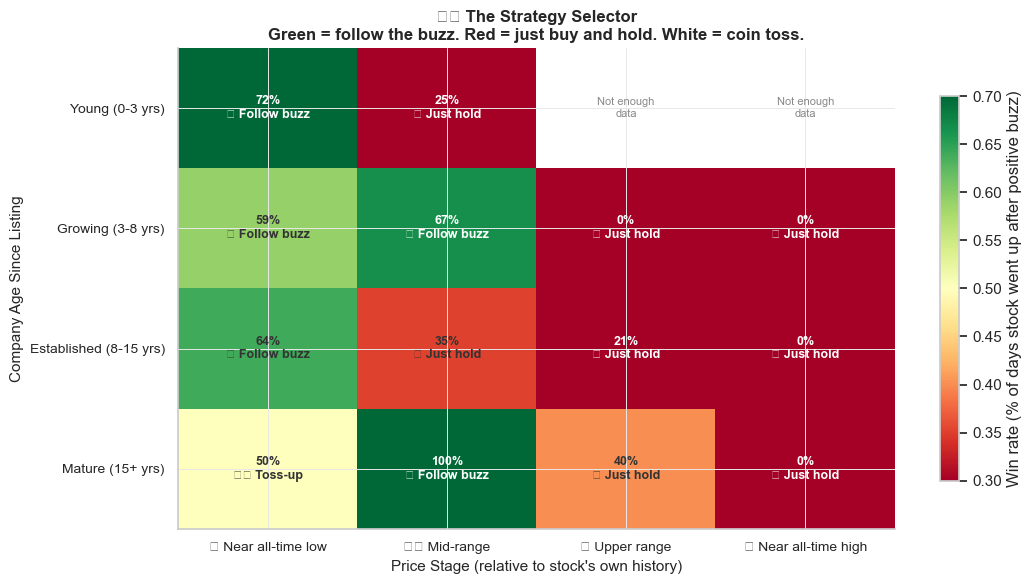


💡 How to read this grid:
   Each box = a combination of company age (rows) and where the stock sits in its price history (columns).
   The % = how often the stock went UP the day after positive internet buzz in that situation.
   Above 55% → buzz is a useful signal. Below 45% → just holding is probably smarter.


In [24]:
# ── Chart 18: The Strategy Selector ───────────────────────────────────────
# 2x2 heatmap: age bucket (rows) vs price stage (cols)
# Color = win rate of buzz strategy in that combination
# Tells you: WHEN should you follow buzz vs just hold?

pivot_data = (
    df_lifecycle
    .assign(pos_buzz = df_lifecycle["sentiment"] >= SENTIMENT_THRESHOLD)
    .groupby(["age_bucket", "price_stage"])
    .apply(lambda g: (g.loc[g["pos_buzz"], "ret_t1"] > 0).mean() if g["pos_buzz"].any() else np.nan)
    .reset_index()
)
pivot_data.columns = ["age_bucket", "price_stage", "win_rate"]

pivot_table = pivot_data.pivot(index="age_bucket", columns="price_stage", values="win_rate")
pivot_table = pivot_table.reindex(index=age_order, columns=stage_order)

fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")
im = ax.imshow(pivot_table.values, cmap="RdYlGn", vmin=0.3, vmax=0.7, aspect="auto")

ax.set_xticks(range(len(stage_order)))
ax.set_yticks(range(len(age_order)))
ax.set_xticklabels([f"{stage_emojis.get(s, '')} {s}" for s in stage_order], fontsize=10)
ax.set_yticklabels(age_order, fontsize=10)
ax.set_xlabel("Price Stage (relative to stock's own history)", fontsize=11)
ax.set_ylabel("Company Age Since Listing", fontsize=11)

# Annotate each cell
for i in range(len(age_order)):
    for j in range(len(stage_order)):
        val = pivot_table.values[i, j]
        if not np.isnan(val):
            text = f"{val*100:.0f}%"
            verdict = "✅ Follow buzz" if val >= 0.55 else ("❌ Just hold" if val < 0.45 else "⚖️ Toss-up")
            ax.text(j, i, f"{text}\n{verdict}",
                    ha="center", va="center", fontsize=9, fontweight="bold",
                    color="white" if (val > 0.65 or val < 0.35) else "#333333")
        else:
            ax.text(j, i, "Not enough\ndata", ha="center", va="center",
                    fontsize=8, color="#888888")

plt.colorbar(im, ax=ax, label="Win rate (% of days stock went up after positive buzz)",
             shrink=0.8)
ax.set_facecolor("white")
ax.set_title(
    "🗺️ The Strategy Selector\n"
    "Green = follow the buzz. Red = just buy and hold. White = coin toss.",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()
print("\n💡 How to read this grid:")
print("   Each box = a combination of company age (rows) and where the stock sits in its price history (columns).")
print("   The % = how often the stock went UP the day after positive internet buzz in that situation.")
print("   Above 55% → buzz is a useful signal. Below 45% → just holding is probably smarter.")